# DETEKSI TRANSAKSI E-COMMERCE SOLATION FOREST (IF)

Notebook ini sudah **dibuat** untuk dataset yang berisikan transaksi E-Commerce non-fraud dan fraud.

## 1) IMPORT & CONFIGURATION

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score, recall_score, f1_score, 
    matthews_corrcoef, confusion_matrix,
    precision_recall_curve, auc, 
    average_precision_score, roc_curve,
    classification_report
)

# System monitoring
import psutil
import time

# Model persistence
import joblib
import json
import pickle

# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
DATA_PATH = r"D:\Alvin\UBM\Skripsi\coding\PS_20174392719_1491204439457_log.csv"
OUTPUT_DIR = Path("./baseline_results")
OUTPUT_DIR.mkdir(exist_ok=True)

# Random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Column definitions
ID_COLS = ['nameOrig', 'nameDest']           # Customer & Merchant IDs (hashed)
SYSTEM_FLAG_COLS = ['isFlaggedFraud']        # System's own fraud flag (avoid leakage)
TARGET_COL = 'isFraud'                       # Target variable
AMOUNT_COL = 'amount'                        # Transaction amount
DROP_COLS = ID_COLS + SYSTEM_FLAG_COLS + [TARGET_COL]

# -----------------------------------------------------------------------------
# System Information
# -----------------------------------------------------------------------------
print("="*80)
print("DETEKSI FRAUD DALAM TRANSAKSI E-COMMERCE")
print("Algoritma: ISOLATION FOREST")
print("="*80)
print(f"\nConfiguration:")
print(f"  Random State: {RANDOM_STATE}")
print(f"  Data Path: {Path(DATA_PATH).name}")
print(f"  Output Dir: {OUTPUT_DIR}")
print(f"\nSystem Specs:")
print(f"  CPU Cores: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"  RAM Total: {psutil.virtual_memory().total / (1024**3):.1f} GB")
print("="*80)


DETEKSI FRAUD DALAM TRANSAKSI E-COMMERCE
Algoritma: ISOLATION FOREST

Configuration:
  Random State: 42
  Data Path: PS_20174392719_1491204439457_log.csv
  Output Dir: baseline_results

System Specs:
  CPU Cores: 8 physical, 16 logical
  RAM Total: 15.7 GB


## 2) LOAD DATA

In [16]:
print("\n[STEP 2] Loading dataset and validating schema")
print("="*80)

# Load dataset
print("Loading dataset...")
df_full = pd.read_csv(DATA_PATH)
df = df_full.copy()

print(f"\nDataset loaded successfully!")
print(f"  Total rows: {len(df_full):,}")
print(f"  Total columns: {len(df_full.columns)}")

# Display column names
print(f"\nColumns in dataset:")
for i, col in enumerate(df_full.columns, 1):
    print(f"  {i:2d}. {col}")

# Validate expected columns
print(f"\n[2.1] Validating expected columns...")

required_cols = {
    'Target': TARGET_COL,
    'Amount': AMOUNT_COL,
    'ID Columns': ID_COLS,
    'System Flags': SYSTEM_FLAG_COLS
}

missing_cols = []
for col_type, cols in required_cols.items():
    if isinstance(cols, list):
        for col in cols:
            if col not in df_full.columns:
                missing_cols.append(f"{col} ({col_type})")
    else:
        if cols not in df_full.columns:
            missing_cols.append(f"{cols} ({col_type})")

if missing_cols:
    print(f"\nERROR: Missing expected columns!")
    print(f"Missing: {missing_cols}")
    print(f"Available columns: {df_full.columns.tolist()}")
    raise ValueError(f"Dataset schema mismatch! Missing: {missing_cols}")

print(f"All expected columns found!")

# Analyze target variable
print(f"\n[2.2] Target variable analysis...")
print(f"Analyzing column: '{TARGET_COL}'")

fraud_counts_full = df_full[TARGET_COL].value_counts()
fraud_rate_full = df_full[TARGET_COL].mean()

print(f"\nClass distribution (full dataset):")
print(fraud_counts_full)
print(f"\nFraud rate: {fraud_rate_full:.4%}")

# Validate target distribution
if fraud_rate_full == 0:
    raise ValueError("ERROR: No fraud cases found in dataset!")
if fraud_rate_full == 1:
    raise ValueError("ERROR: All cases are fraud!")

print(f"Target variable is valid (fraud rate: {fraud_rate_full:.4%})")

# Validate data types
print(f"\n[2.3] Validating data types...")

if not pd.api.types.is_numeric_dtype(df_full[AMOUNT_COL]):
    raise TypeError(f"Column '{AMOUNT_COL}' must be numeric!")

if not pd.api.types.is_integer_dtype(df_full[TARGET_COL]):
    raise TypeError(f"Column '{TARGET_COL}' must be integer (0 or 1)!")

# Check target values
unique_targets = df_full[TARGET_COL].unique()
if not set(unique_targets).issubset({0, 1}):
    raise ValueError(f"Column '{TARGET_COL}' must only contain 0 or 1, found: {unique_targets}")

print(f"Data types validated successfully!")

# Check missing values in critical columns
print(f"\n[2.4] Checking missing values in critical columns...")

critical_cols = [TARGET_COL, AMOUNT_COL] + ID_COLS
missing = df_full[critical_cols].isnull().sum()

if missing.sum() > 0:
    print(f"WARNING: Missing values found in critical columns!")
    print(missing[missing > 0])
else:
    print(f"No missing values in critical columns!")

print(f"\nStep 2 completed successfully!")
print("="*80)


[STEP 2] Loading dataset and validating schema
Loading dataset...

Dataset loaded successfully!
  Total rows: 6,362,620
  Total columns: 11

Columns in dataset:
   1. step
   2. type
   3. amount
   4. nameOrig
   5. oldbalanceOrg
   6. newbalanceOrig
   7. nameDest
   8. oldbalanceDest
   9. newbalanceDest
  10. isFraud
  11. isFlaggedFraud

[2.1] Validating expected columns...
All expected columns found!

[2.2] Target variable analysis...
Analyzing column: 'isFraud'

Class distribution (full dataset):
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud rate: 0.1291%
Target variable is valid (fraud rate: 0.1291%)

[2.3] Validating data types...
Data types validated successfully!

[2.4] Checking missing values in critical columns...
No missing values in critical columns!

Step 2 completed successfully!


### 2.5)UNDERSAMPLING & DATA ALLOCATION

In [17]:
print("\n[STEP 2.5] Data Sampling Strategy: Undersampling Normal Class")
print("="*80)

# Dataset overview
print("\nDataset overview:")
print(f"  Total data available: {len(df):,}")
print(f"  Fraud:  {(df[TARGET_COL]==1).sum():,}")
print(f"  Normal: {(df[TARGET_COL]==0).sum():,}")

# Separate classes
df_fraud_all = df[df[TARGET_COL] == 1].copy()
df_normal_all = df[df[TARGET_COL] == 0].copy()

print("\nAvailable by class:")
print(f"  Fraud:  {len(df_fraud_all):,}")
print(f"  Normal: {len(df_normal_all):,}")

# Define allocation strategy
N_FRAUD_FOR_TRAINING = 6500
RATIO = 1.2  # Normal:Fraud ratio
N_NORMAL_FOR_TRAINING = int(N_FRAUD_FOR_TRAINING * RATIO)

N_FRAUD_FOR_DEMO = len(df_fraud_all) - N_FRAUD_FOR_TRAINING
N_NORMAL_FOR_DEMO = 2000

print("\n[2.5.1] Allocation Plan:")
print("-" * 80)
print(f"Training Pool (Train-Val-Test split):")
print(f"  Fraud:  {N_FRAUD_FOR_TRAINING:,}")
print(f"  Normal: {N_NORMAL_FOR_TRAINING:,} (ratio {RATIO}:1)")
print(f"  Total:  {N_FRAUD_FOR_TRAINING + N_NORMAL_FOR_TRAINING:,}")
print(f"\nDemo Set (for presentation):")
print(f"  Fraud:  {N_FRAUD_FOR_DEMO:,}")
print(f"  Normal: {N_NORMAL_FOR_DEMO:,}")
print(f"  Total:  {N_FRAUD_FOR_DEMO + N_NORMAL_FOR_DEMO:,}")

# Create training pool
print("\n[2.5.2] Creating Training Pool...")
print("-" * 80)

# Sample fraud for training
df_fraud_training = df_fraud_all.sample(n=N_FRAUD_FOR_TRAINING, random_state=RANDOM_STATE)
print(f"Sampled {N_FRAUD_FOR_TRAINING:,} fraud cases for training")

# Sample normal for training
df_normal_training = df_normal_all.sample(n=N_NORMAL_FOR_TRAINING, random_state=RANDOM_STATE)
print(f"Sampled {N_NORMAL_FOR_TRAINING:,} normal cases for training")

# Combine and shuffle
df_training_pool = pd.concat([df_fraud_training, df_normal_training], axis=0)
df_training_pool = df_training_pool.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"\nTraining Pool created:")
print(f"  Fraud:  {(df_training_pool[TARGET_COL]==1).sum():,} ({(df_training_pool[TARGET_COL]==1).mean()*100:.2f}%)")
print(f"  Normal: {(df_training_pool[TARGET_COL]==0).sum():,} ({(df_training_pool[TARGET_COL]==0).mean()*100:.2f}%)")
print(f"  Total:  {len(df_training_pool):,}")

# Create demo set
print("\n[2.5.3] Creating Demo Set...")
print("-" * 80)

# Remaining fraud (not used in training)
df_fraud_remaining = df_fraud_all.drop(df_fraud_training.index)
print(f"Fraud remaining: {len(df_fraud_remaining):,}")

# Sample normal for demo (not used in training)
df_normal_remaining = df_normal_all.drop(df_normal_training.index)
df_normal_demo = df_normal_remaining.sample(n=N_NORMAL_FOR_DEMO, random_state=RANDOM_STATE)
print(f"Sampled {N_NORMAL_FOR_DEMO:,} normal cases for demo")

# Combine demo set
df_demo = pd.concat([df_fraud_remaining, df_normal_demo], axis=0)
df_demo = df_demo.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"\nDemo Set created:")
print(f"  Fraud:  {(df_demo[TARGET_COL]==1).sum():,} ({(df_demo[TARGET_COL]==1).mean()*100:.2f}%)")
print(f"  Normal: {(df_demo[TARGET_COL]==0).sum():,} ({(df_demo[TARGET_COL]==0).mean()*100:.2f}%)")
print(f"  Total:  {len(df_demo):,}")

# Save demo set
print("\n[2.5.4] Saving Demo Set...")
print("-" * 80)

# Save demo data without labels (for prediction)
df_demo_no_label = df_demo.drop(columns=[TARGET_COL])
df_demo_no_label.to_csv(OUTPUT_DIR / 'demo_transactions.csv', index=False)
print(f"Saved: demo_transactions.csv ({len(df_demo_no_label):,} rows)")

# Save ground truth (for evaluation)
df_demo_truth = pd.DataFrame({
    'Index': range(len(df_demo)),
    'True_Label': df_demo[TARGET_COL].values,
    'Label_Text': ['FRAUD' if x == 1 else 'NORMAL' for x in df_demo[TARGET_COL].values]
})
df_demo_truth.to_csv(OUTPUT_DIR / 'demo_ground_truth.csv', index=False)
print(f"Saved: demo_ground_truth.csv")

# Update dataframe for next steps
df = df_training_pool.copy()

# Summary
print("\n" + "="*80)
print("DATA SPLIT COMPLETED")
print("="*80)
print(f"\nSummary:")
print(f"  Training Pool (will be split 70-15-15):")
print(f"    Total: {len(df):,} rows")
print(f"    Fraud: {(df[TARGET_COL]==1).sum():,} ({(df[TARGET_COL]==1).mean()*100:.2f}%)")
print(f"    Normal:Fraud Ratio = {RATIO}:1")
print(f"\n  Demo Set (for presentation):")
print(f"    Total: {len(df_demo):,} rows")
print(f"    Fraud: {(df_demo[TARGET_COL]==1).sum():,} ({(df_demo[TARGET_COL]==1).mean()*100:.2f}%)")
print(f"    Normal: {(df_demo[TARGET_COL]==0).sum():,} ({(df_demo[TARGET_COL]==0).mean()*100:.2f}%)")

# Save split information
split_info = {
    'strategy': 'Undersampling',
    'training_pool': {
        'total': int(len(df)),
        'fraud': int((df[TARGET_COL]==1).sum()),
        'normal': int((df[TARGET_COL]==0).sum()),
        'fraud_pct': float((df[TARGET_COL]==1).mean()*100),
        'ratio': float(RATIO)
    },
    'demo_set': {
        'total': int(len(df_demo)),
        'fraud': int((df_demo[TARGET_COL]==1).sum()),
        'normal': int((df_demo[TARGET_COL]==0).sum()),
        'fraud_pct': float((df_demo[TARGET_COL]==1).mean()*100)
    },
    'random_state': RANDOM_STATE
}

with open(OUTPUT_DIR / 'data_split_info.json', 'w') as f:
    json.dump(split_info, f, indent=2)

print(f"\nSplit info saved to: {OUTPUT_DIR / 'data_split_info.json'}")
print("="*80)


[STEP 2.5] Data Sampling Strategy: Undersampling Normal Class

Dataset overview:
  Total data available: 6,362,620
  Fraud:  8,213
  Normal: 6,354,407

Available by class:
  Fraud:  8,213
  Normal: 6,354,407

[2.5.1] Allocation Plan:
--------------------------------------------------------------------------------
Training Pool (Train-Val-Test split):
  Fraud:  6,500
  Normal: 7,800 (ratio 1.2:1)
  Total:  14,300

Demo Set (for presentation):
  Fraud:  1,713
  Normal: 2,000
  Total:  3,713

[2.5.2] Creating Training Pool...
--------------------------------------------------------------------------------
Sampled 6,500 fraud cases for training
Sampled 7,800 normal cases for training

Training Pool created:
  Fraud:  6,500 (45.45%)
  Normal: 7,800 (54.55%)
  Total:  14,300

[2.5.3] Creating Demo Set...
--------------------------------------------------------------------------------
Fraud remaining: 1,713
Sampled 2,000 normal cases for demo

Demo Set created:
  Fraud:  1,713 (46.14%)
  Nor

## 3) EXPLORATORY DATA ANALYSIS (EDA)


[STEP 3] Exploratory Data Analysis...

[3.1] Data Quality Check
------------------------------------------------------------
✓ No missing values
Duplicate rows: 0

Data types:
float64    5
int64      3
object     3
Name: count, dtype: int64

[3.2] Target Variable Analysis
------------------------------------------------------------
Class distribution:
  Normal (0): 7,800 (54.55%)
  Fraud (1): 6,500 (45.45%)
  Imbalance ratio: 1:1.2
✓ Saved: eda_target_distribution.png

[3.3] Numerical Features Analysis
------------------------------------------------------------
Numerical features (7):
  - step
  - amount
  - oldbalanceOrg
  - newbalanceOrig
  - oldbalanceDest
  - newbalanceDest
  - isFlaggedFraud

Descriptive statistics:
                  count          mean           std  min         25%  \
step            14300.0  3.002940e+02  1.904415e+02  1.0    160.0000   
amount          14300.0  7.716486e+05  1.803078e+06  0.0  33740.3900   
oldbalanceOrg   14300.0  1.215482e+06  3.221460e+06

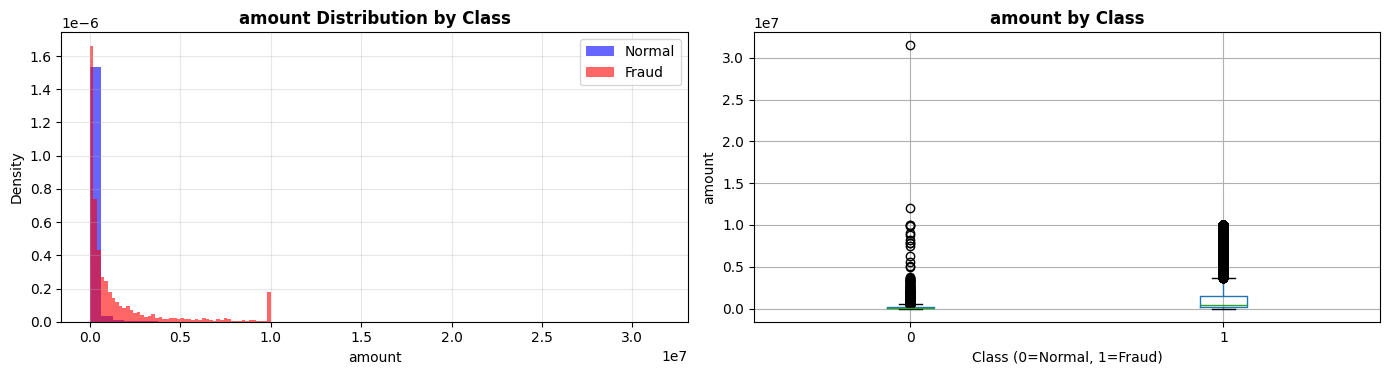

✓ Saved: eda_amount_distribution.png

[3.4] Transaction Type Analysis
------------------------------------------------------------

Transaction type distribution:
type
CASH_OUT    6086
TRANSFER    3830
PAYMENT     2592
CASH_IN     1745
DEBIT         47
Name: count, dtype: int64

Fraud rate by Transaction Type:
          Fraud_Count  Total  Fraud_Rate
type                                    
TRANSFER         3215   3830    0.839426
CASH_OUT         3285   6086    0.539763
CASH_IN             0   1745    0.000000
DEBIT               0     47    0.000000
PAYMENT             0   2592    0.000000


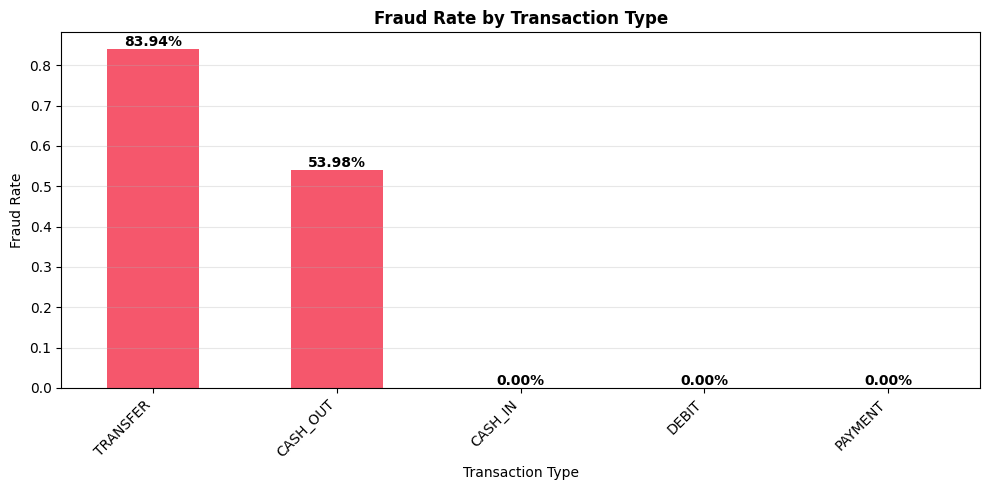

✓ Saved: eda_fraud_by_type.png

[3.5] Correlation Analysis (BEFORE Feature Engineering)
------------------------------------------------------------
Computing correlation matrix...

Top features correlated with fraud:
isFraud           1.000000
amount            0.358753
step              0.320677
newbalanceOrig    0.132877
oldbalanceOrg     0.125907
oldbalanceDest    0.076199
isFlaggedFraud    0.030394
newbalanceDest    0.006662
Name: isFraud, dtype: float64

Creating correlation heatmap...


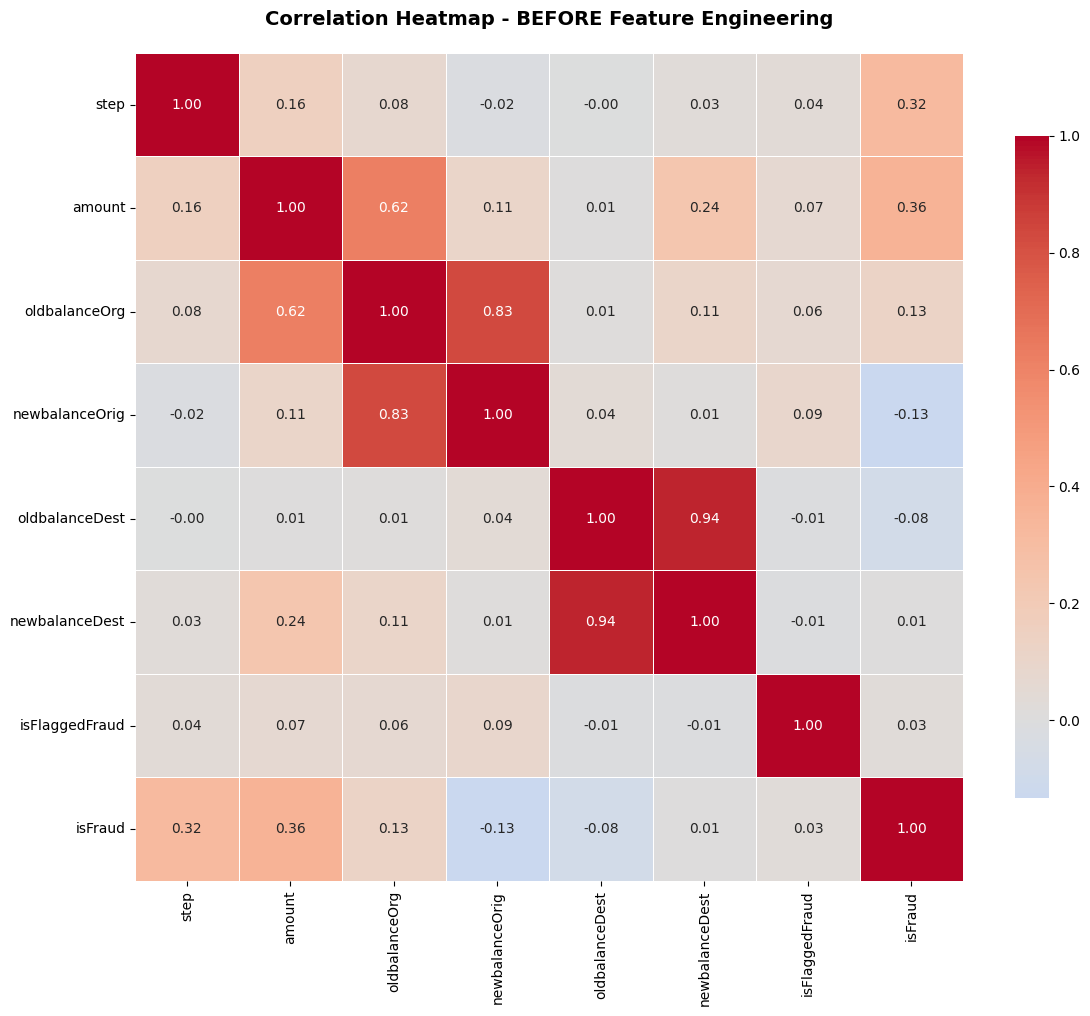

✓ Saved: eda_correlation_before.png

✓ EDA completed! Check baseline_results for visualizations.


In [20]:
print("\n[STEP 3] Exploratory Data Analysis...")
print("="*80)

# 3.1) Data Quality Check
print("\n[3.1] Data Quality Check")
print("-" * 60)

# Missing values
missing = df.isnull().sum()
if missing.sum() > 0:
    print("Missing values found:")
    print(missing[missing > 0])
else:
    print("✓ No missing values")

# Duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates:,}")
if duplicates > 0:
    print("  Removing duplicates...")
    df = df.drop_duplicates()
    print(f"  ✓ After removal: {len(df):,} rows")

# Data types
print(f"\nData types:")
print(df.dtypes.value_counts())

# 3.2) Target Distribution
print("\n[3.2] Target Variable Analysis")
print("-" * 60)

fraud_counts = df[TARGET_COL].value_counts()
print(f"Class distribution:")
print(f"  Normal (0): {fraud_counts[0]:,} ({fraud_counts[0]/len(df)*100:.2f}%)")
print(f"  Fraud (1): {fraud_counts[1]:,} ({fraud_counts[1]/len(df)*100:.2f}%)")
print(f"  Imbalance ratio: 1:{fraud_counts[0]/fraud_counts[1]:.1f}")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
fraud_counts.plot(kind='bar', ax=ax, color=['#4facfe', '#f5576c'])
ax.set_title('Target Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(['Normal', 'Fraud'], rotation=0)
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(fraud_counts.values):
    ax.text(i, v, f'{v:,}\n({v/len(df)*100:.1f}%)', 
            ha='center', va='bottom', fontweight='bold')

ax = axes[1]
ax.pie(fraud_counts.values, labels=['Normal', 'Fraud'], 
       autopct='%1.2f%%', colors=['#4facfe', '#f5576c'],
       startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title('Class Proportion', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_target_distribution.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Saved: eda_target_distribution.png")

# 3.3) Numerical Features Analysis
print("\n[3.3] Numerical Features Analysis")
print("-" * 60)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COL in numerical_cols:
    numerical_cols.remove(TARGET_COL)

print(f"Numerical features ({len(numerical_cols)}):")
for col in numerical_cols:
    print(f"  - {col}")

print(f"\nDescriptive statistics:")
print(df[numerical_cols].describe().T)

# Amount distribution by fraud
if AMOUNT_COL in df.columns:
    print(f"\n{AMOUNT_COL} distribution by class:")
    print(df.groupby(TARGET_COL)[AMOUNT_COL].describe())
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    ax = axes[0]
    df[df[TARGET_COL] == 0][AMOUNT_COL].hist(bins=50, ax=ax, alpha=0.6, 
                                               label='Normal', color='blue', density=True)
    df[df[TARGET_COL] == 1][AMOUNT_COL].hist(bins=50, ax=ax, alpha=0.6, 
                                               label='Fraud', color='red', density=True)
    ax.set_xlabel(AMOUNT_COL)
    ax.set_ylabel('Density')
    ax.set_title(f'{AMOUNT_COL} Distribution by Class', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    
    ax = axes[1]
    df.boxplot(column=AMOUNT_COL, by=TARGET_COL, ax=ax)
    ax.set_xlabel('Class (0=Normal, 1=Fraud)')
    ax.set_ylabel(AMOUNT_COL)
    ax.set_title(f'{AMOUNT_COL} by Class', fontweight='bold')
    plt.suptitle('')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'eda_amount_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: eda_amount_distribution.png")

# 3.4) Transaction Type Analysis (NEW!)
print("\n[3.4] Transaction Type Analysis")
print("-" * 60)

if 'type' in df.columns:
    print(f"\nTransaction type distribution:")
    print(df['type'].value_counts())
    
    print(f"\nFraud rate by Transaction Type:")
    fraud_by_type = df.groupby('type')[TARGET_COL].agg(['sum', 'count', 'mean'])
    fraud_by_type.columns = ['Fraud_Count', 'Total', 'Fraud_Rate']
    fraud_by_type = fraud_by_type.sort_values('Fraud_Rate', ascending=False)
    print(fraud_by_type)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 5))
    fraud_by_type['Fraud_Rate'].plot(kind='bar', ax=ax, color='#f5576c')
    ax.set_title('Fraud Rate by Transaction Type', fontsize=12, fontweight='bold')
    ax.set_xlabel('Transaction Type')
    ax.set_ylabel('Fraud Rate')
    ax.set_xticklabels(fraud_by_type.index, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(fraud_by_type['Fraud_Rate'].values):
        ax.text(i, v, f'{v:.2%}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'eda_fraud_by_type.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: eda_fraud_by_type.png")

# 3.5) Correlation Analysis (BEFORE Feature Engineering)
print("\n[3.5] Correlation Analysis (BEFORE Feature Engineering)")
print("-" * 60)

numerical_for_corr = df[numerical_cols + [TARGET_COL]].copy()
print("Computing correlation matrix...")
corr_matrix = numerical_for_corr.corr()

corr_with_target = corr_matrix[TARGET_COL].abs().sort_values(ascending=False)
print(f"\nTop features correlated with fraud:")
print(corr_with_target.head(11))

print("\nCreating correlation heatmap...")
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            annot=True, fmt='.2f')
plt.title('Correlation Heatmap - BEFORE Feature Engineering', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_correlation_before.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: eda_correlation_before.png")

print(f"\n✓ EDA completed! Check {OUTPUT_DIR} for visualizations.")


## 4) FEATURE ENGINEERING

In [ ]:
print("\n[STEP 4] Feature Engineering...")
print("="*80)

df_fe = df.copy()
new_features = []

# 4.1) Time-based Features (from 'step' column)
print("\n[4.1] Creating Time-based Features...")
print("-" * 60)

if 'step' in df_fe.columns:
    print("Processing 'step' column (1 step = 1 hour)...")
    
    # Convert step to hour of day (assume step wraps around 24 hours)
    df_fe['Hour'] = df_fe['step'] % 24
    df_fe['Day'] = df_fe['step'] // 24
    
    # Time-based flags
    df_fe['IsNight'] = ((df_fe['Hour'] >= 22) | (df_fe['Hour'] <= 6)).astype(int)
    df_fe['IsBusinessHours'] = ((df_fe['Hour'] >= 9) & (df_fe['Hour'] <= 17)).astype(int)
    
    new_features.extend(['Hour', 'Day', 'IsNight', 'IsBusinessHours'])
    print(f"✓ Created {len(new_features)} time features: {new_features}")

# 4.2) Amount-based Features
print("\n[4.2] Creating Amount-based Features...")
print("-" * 60)

if AMOUNT_COL in df_fe.columns:
    print(f"Processing '{AMOUNT_COL}' column...")
    
    df_fe['amount_log'] = np.log1p(df_fe[AMOUNT_COL])
    df_fe['amount_sqrt'] = np.sqrt(df_fe[AMOUNT_COL])
    
    new_features.extend(['amount_log', 'amount_sqrt'])
    print(f"✓ Created 2 amount features")

# 4.3) Balance-based Features (NEW - specific to this dataset!)
print("\n[4.3] Creating Balance-based Features...")
print("-" * 60)

if all(col in df_fe.columns for col in ['oldbalanceOrg', 'newbalanceOrig']):
    print("Processing balance features for SENDER...")
    
    # Balance change for sender
    df_fe['balance_change_orig'] = df_fe['newbalanceOrig'] - df_fe['oldbalanceOrg']
    df_fe['balance_change_orig_pct'] = df_fe['balance_change_orig'] / (df_fe['oldbalanceOrg'] + 1)
    
    # Is sender balance depleted?
    df_fe['sender_depleted'] = (df_fe['newbalanceOrig'] == 0).astype(int)
    
    new_features.extend(['balance_change_orig', 'balance_change_orig_pct', 'sender_depleted'])
    print(f"✓ Created 3 sender balance features")

if all(col in df_fe.columns for col in ['oldbalanceDest', 'newbalanceDest']):
    print("Processing balance features for RECEIVER...")
    
    # Balance change for receiver
    df_fe['balance_change_dest'] = df_fe['newbalanceDest'] - df_fe['oldbalanceDest']
    df_fe['balance_change_dest_pct'] = df_fe['balance_change_dest'] / (df_fe['oldbalanceDest'] + 1)
    
    # Does receiver start with 0 balance?
    df_fe['receiver_new_account'] = (df_fe['oldbalanceDest'] == 0).astype(int)
    
    new_features.extend(['balance_change_dest', 'balance_change_dest_pct', 'receiver_new_account'])
    print(f"✓ Created 3 receiver balance features")

# 4.4) Transaction Consistency Check (NEW - important for fraud!)
print("\n[4.4] Creating Transaction Consistency Features...")
print("-" * 60)

if all(col in df_fe.columns for col in ['amount', 'oldbalanceOrg', 'newbalanceOrig']):
    print("Checking transaction consistency...")
    
    # Expected balance after transaction
    df_fe['expected_balance_orig'] = df_fe['oldbalanceOrg'] - df_fe['amount']
    
    # Inconsistency flag (for CASH_OUT and TRANSFER)
    df_fe['balance_inconsistent'] = (
        (df_fe['expected_balance_orig'] != df_fe['newbalanceOrig']) & 
        (df_fe['type'].isin(['CASH_OUT', 'TRANSFER']))
    ).astype(int)
    
    new_features.extend(['expected_balance_orig', 'balance_inconsistent'])
    print(f"✓ Created 2 consistency features")

# 4.5) Encode Categorical Variables
print("\n[4.5] Encoding Categorical Variables...")
print("-" * 60)

label_encoders = {}
categorical_cols_to_encode = df_fe.select_dtypes(include=['object']).columns.tolist()
categorical_cols_to_encode = [col for col in categorical_cols_to_encode 
                               if col not in DROP_COLS and col in df_fe.columns]

print(f"Categorical columns to encode ({len(categorical_cols_to_encode)}):")
for col in categorical_cols_to_encode:
    n_unique = df_fe[col].nunique()
    print(f"  - {col}: {n_unique:,} unique values")

if len(categorical_cols_to_encode) > 0:
    for col in categorical_cols_to_encode:
        print(f"\nEncoding '{col}'...")
        le = LabelEncoder()
        df_fe[f'{col}_encoded'] = le.fit_transform(df_fe[col].astype(str))
        label_encoders[col] = le
        new_features.append(f'{col}_encoded')
        print(f"  ✓ Created: {col}_encoded")

# Summary
print(f"\n{'='*80}")
print(f"✓ FEATURE ENGINEERING COMPLETED!")
print(f"{'='*80}")
print(f"  Original features: {len(df.columns)}")
print(f"  New features created: {len(new_features)}")
print(f"  Total features now: {len(df_fe.columns)}")
print(f"  Data shape: {df_fe.shape}")

print(f"\n📋 New Features List:")
for i, feat in enumerate(new_features, 1):
    print(f"    {i:2d}. {feat}")

# Save label encoders
if len(label_encoders) > 0:
    with open(OUTPUT_DIR / 'label_encoders.pkl', 'wb') as f:
        pickle.dump(label_encoders, f)
    print(f"\n✓ Saved {len(label_encoders)} label encoders")



[STEP 4] Feature Engineering...

[4.1] Creating Time-based Features...
------------------------------------------------------------
Processing 'step' column (1 step = 1 hour)...
✓ Created 4 time features: ['Hour', 'Day', 'IsNight', 'IsBusinessHours']

[4.2] Creating Amount-based Features...
------------------------------------------------------------
Processing 'amount' column...
✓ Created 2 amount features

[4.3] Creating Balance-based Features...
------------------------------------------------------------
Processing balance features for SENDER...
✓ Created 3 sender balance features
Processing balance features for RECEIVER...
✓ Created 3 receiver balance features

[4.4] Creating Transaction Consistency Features...
------------------------------------------------------------
Checking transaction consistency...
✓ Created 2 consistency features

[4.5] Encoding Categorical Variables...
------------------------------------------------------------
Categorical columns to encode (1):
  - ty

## 5) FEATURE SELECTION


[STEP 5] Feature Selection...

[5.1] Identifying columns to drop...
------------------------------------------------------------

1️⃣ ID Columns (no predictive value):
  ❌ nameOrig: Random hashed ID, tidak ada pola
  ❌ nameDest: Random hashed ID, tidak ada pola

2️⃣ System Flag Columns (avoid data leakage):
  ❌ isFlaggedFraud: System's own detection, causes data leakage

3️⃣ Original Categorical Columns (already encoded):
  ❌ type: Replaced by type_encoded

4️⃣ Time Columns (replaced by engineered features):
  ❌ step: Replaced by Hour, Day, IsNight, IsBusinessHours

📋 Summary - Columns to drop (excluding target): 5
  - isFlaggedFraud
  - nameDest
  - nameOrig
  - step
  - type

[5.2] Extracting target variable...
------------------------------------------------------------
✓ Target variable extracted successfully!
  Column name: isFraud
  Shape: (14300,)
  Data type: int64

  Class distribution:
    Normal (0): 7,800 (54.55%)
    Fraud (1):  6,500 (45.45%)

[5.3] Creating feature matr

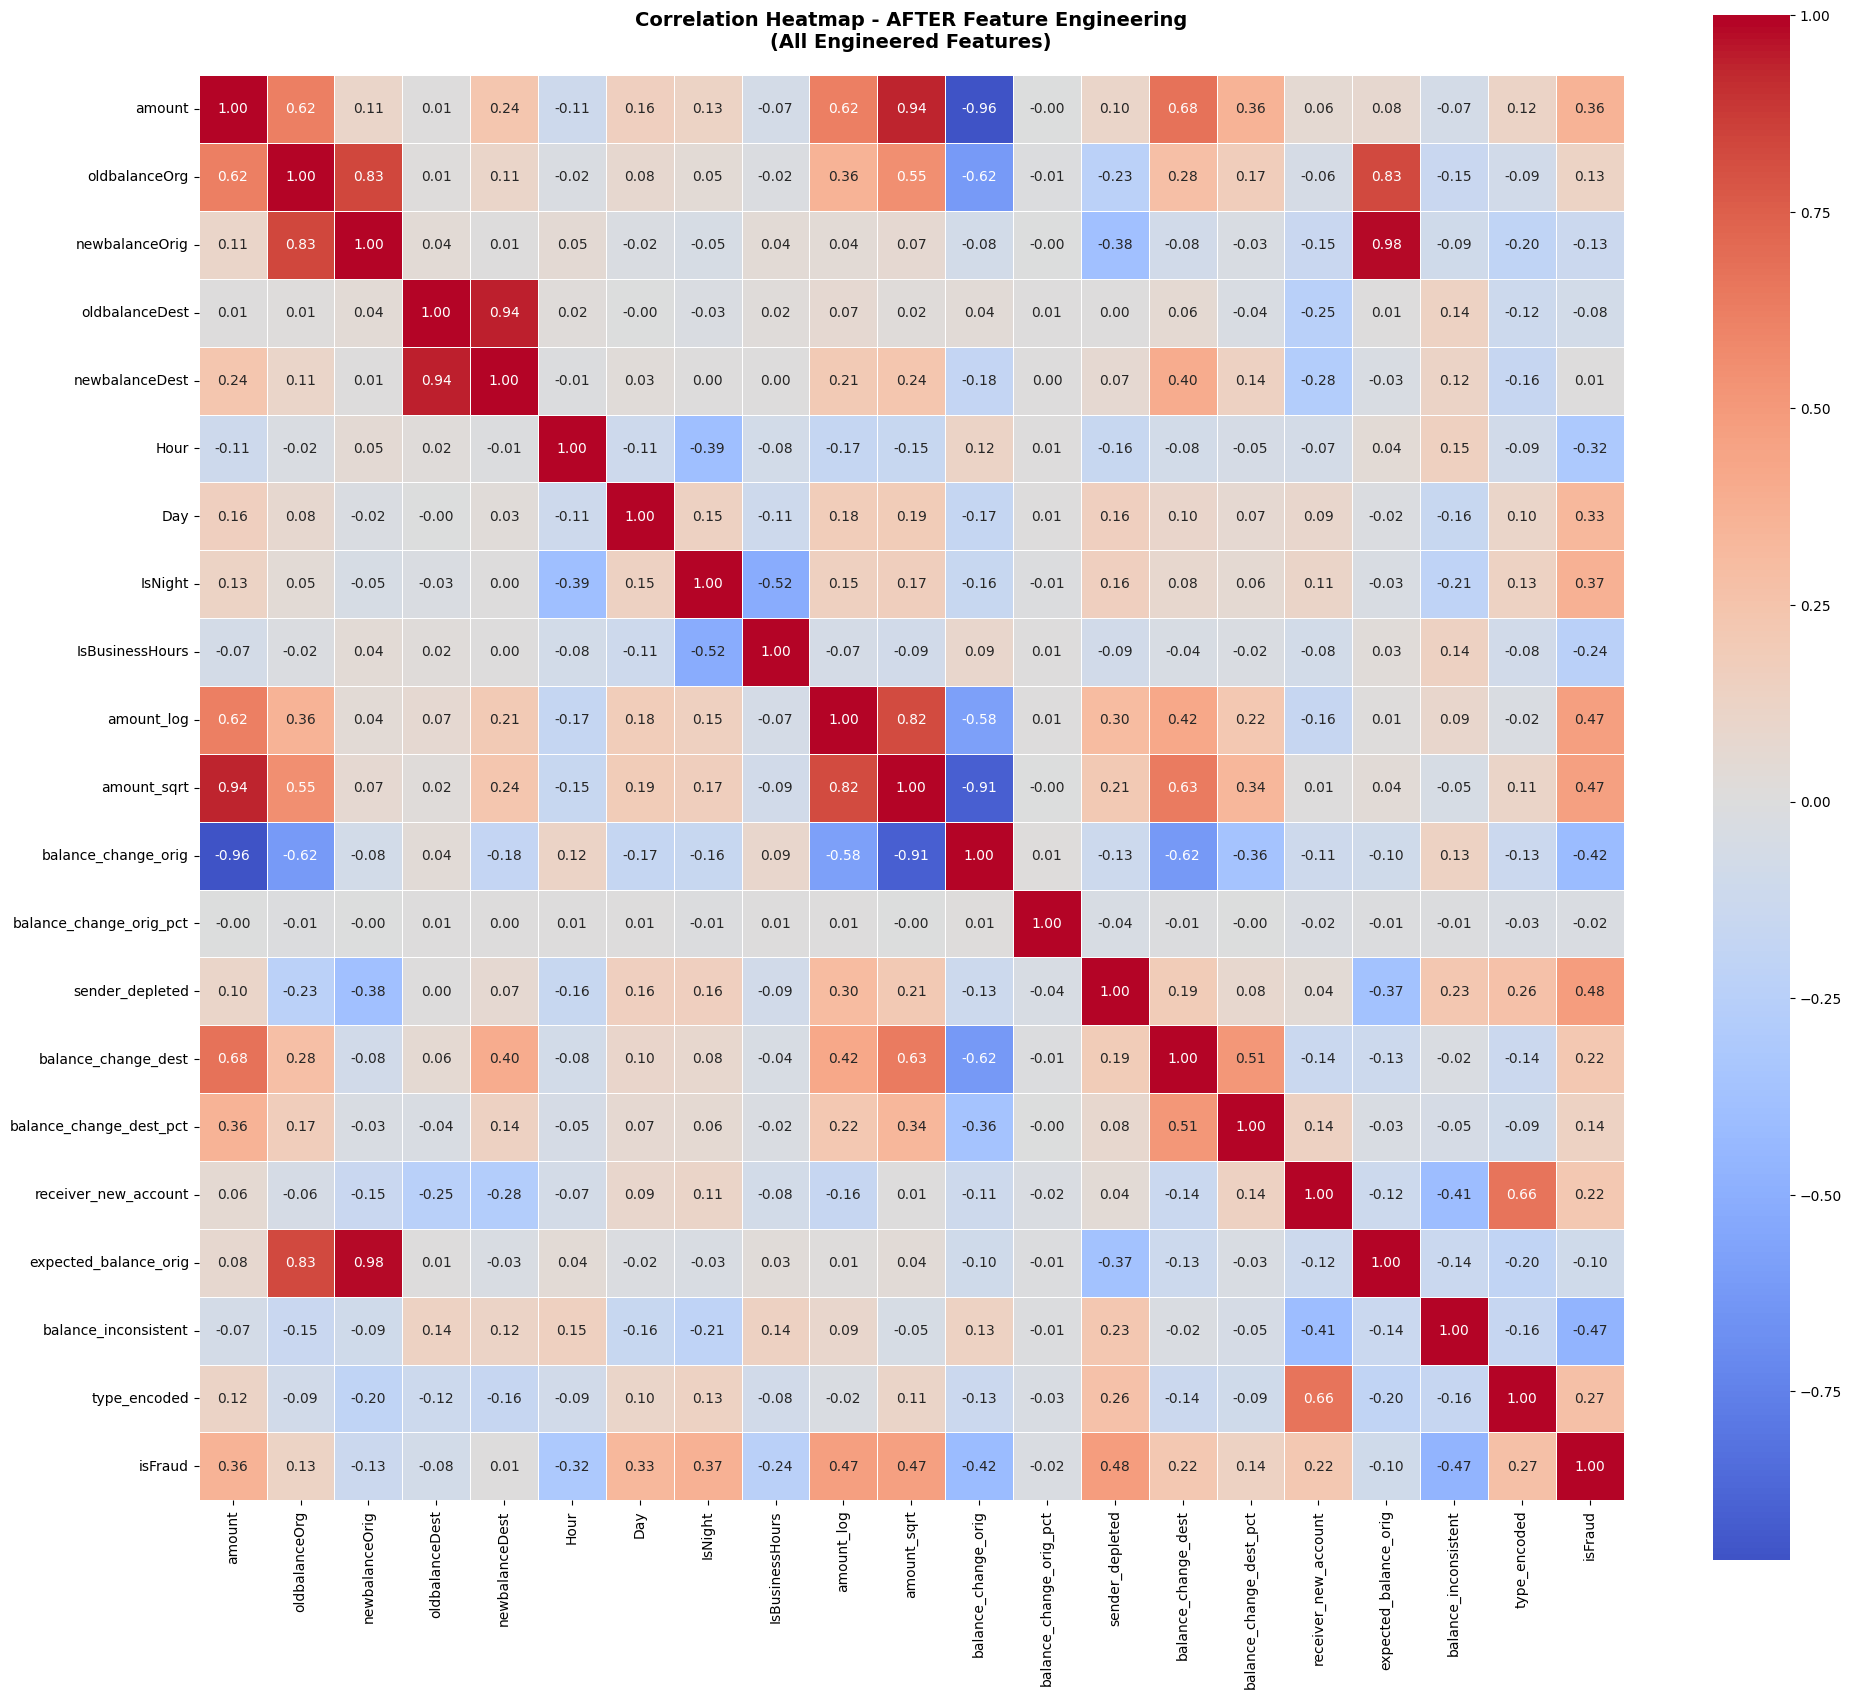

✓ Saved: baseline_results\eda_correlation_after.png

Creating feature importance chart...


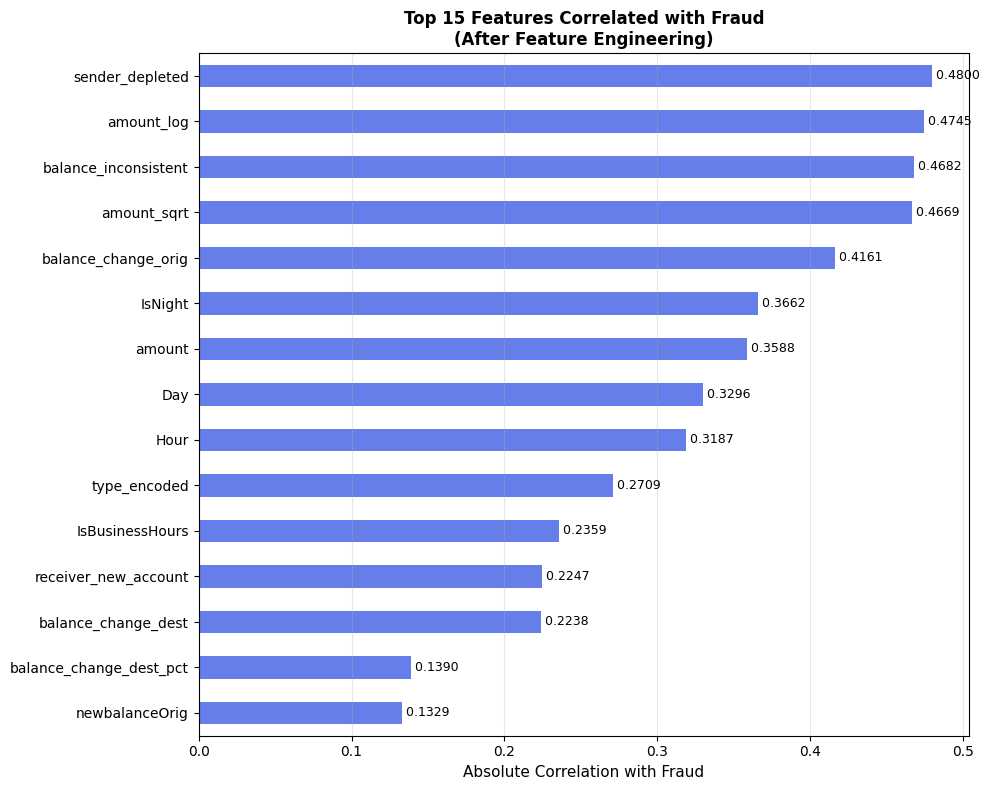

✓ Saved: baseline_results\eda_feature_importance_after.png

✓ FEATURE SELECTION COMPLETED!
  Original columns in df_fe: 26
  Columns dropped: 6
  Final features (X): 20
  Target variable (y): 14,300 samples
  Fraud rate: 45.45%

✓ Ready for next step: Data Splitting (70-15-15)


In [7]:
print("\n[STEP 5] Feature Selection...")
print("="*80)

print("\n[5.1] Identifying columns to drop...")
print("-" * 60)

cols_to_drop = []

# 1. ID Columns (no predictive value)
print("\n1️⃣ ID Columns (no predictive value):")
if 'ID_COLS' in dir():
    for col in ID_COLS:
        if col in df_fe.columns:
            print(f"  ❌ {col}: Random hashed ID, tidak ada pola")
            cols_to_drop.append(col)
else:
    # Fallback if ID_COLS not defined
    for col in ['nameOrig', 'nameDest']:
        if col in df_fe.columns:
            print(f"  ❌ {col}: Random hashed ID")
            cols_to_drop.append(col)

# 2. System Flag Columns (data leakage risk)
print("\n2️⃣ System Flag Columns (avoid data leakage):")
if 'SYSTEM_FLAG_COLS' in dir():
    for col in SYSTEM_FLAG_COLS:
        if col in df_fe.columns:
            print(f"  ❌ {col}: System's own detection, causes data leakage")
            cols_to_drop.append(col)
else:
    # Fallback
    if 'isFlaggedFraud' in df_fe.columns:
        print(f"  ❌ isFlaggedFraud: System's own detection")
        cols_to_drop.append('isFlaggedFraud')

# 3. Original categorical columns (already encoded)
print("\n3️⃣ Original Categorical Columns (already encoded):")
if 'categorical_cols_to_encode' in dir() and len(categorical_cols_to_encode) > 0:
    for col in categorical_cols_to_encode:
        if col in df_fe.columns:
            print(f"  ❌ {col}: Replaced by {col}_encoded")
            cols_to_drop.append(col)
else:
    print("  (None)")

# 4. Original 'step' column (replaced by Hour/Day)
print("\n4️⃣ Time Columns (replaced by engineered features):")
if 'step' in df_fe.columns and 'Hour' in df_fe.columns:
    print(f"  ❌ step: Replaced by Hour, Day, IsNight, IsBusinessHours")
    cols_to_drop.append('step')
else:
    print("  (None)")

# Remove duplicates
cols_to_drop = list(set(cols_to_drop))

print(f"\n📋 Summary - Columns to drop (excluding target): {len(cols_to_drop)}")
for col in sorted(cols_to_drop):
    if col in df_fe.columns:
        print(f"  - {col}")

print(f"\n[5.2] Extracting target variable...")
print("-" * 60)

# Check if target column exists
if TARGET_COL not in df_fe.columns:
    print(f"\n❌ ERROR: Target column '{TARGET_COL}' not found!")
    print(f"Available columns: {df_fe.columns.tolist()}")
    raise ValueError(f"Target column '{TARGET_COL}' not found in df_fe")

# Extract target variable
y = df_fe[TARGET_COL].copy()

print(f"✓ Target variable extracted successfully!")
print(f"  Column name: {TARGET_COL}")
print(f"  Shape: {y.shape}")
print(f"  Data type: {y.dtype}")
print(f"\n  Class distribution:")
print(f"    Normal (0): {(y==0).sum():,} ({(y==0).mean()*100:.2f}%)")
print(f"    Fraud (1):  {(y==1).sum():,} ({(y==1).mean()*100:.2f}%)")

print(f"\n[5.3] Creating feature matrix (X)...")
print("-" * 60)

# Add target to drop list NOW (after we've extracted it safely)
cols_to_drop.append(TARGET_COL)
cols_to_drop = list(set(cols_to_drop))  # Remove duplicates

print(f"Total columns to drop (including target): {len(cols_to_drop)}")

# Drop columns to create feature matrix
X = df_fe.drop(columns=cols_to_drop, errors='ignore')

print(f"\n✓ Feature matrix created successfully!")
print(f"  Shape: {X.shape}")
print(f"  Number of features: {X.shape[1]}")
print(f"  Number of samples: {X.shape[0]:,}")
print(f"  Memory usage: {X.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Check for any remaining issues
print(f"\n✓ Data quality check:")
print(f"  Missing values: {X.isnull().sum().sum()}")
print(f"  Infinite values: {np.isinf(X.select_dtypes(include=[np.number])).sum().sum()}")

# Display final features
print(f"\n📊 Final features for modeling ({len(X.columns)}):")
for i, col in enumerate(X.columns, 1):
    dtype = str(X[col].dtype)
    n_unique = X[col].nunique()
    print(f"  {i:2d}. {col:35s} | dtype: {dtype:10s} | unique: {n_unique:,}")

print(f"\n[5.4] Saving feature list...")
print("-" * 60)

feature_list = X.columns.tolist()

# Save to JSON
feature_info = {
    'feature_names': feature_list,
    'n_features': len(feature_list),
    'target_column': TARGET_COL,
    'dropped_columns': sorted([col for col in cols_to_drop if col != TARGET_COL])
}

with open(OUTPUT_DIR / 'feature_list.json', 'w') as f:
    json.dump(feature_info, f, indent=2)

print(f"✓ Saved feature list to: {OUTPUT_DIR / 'feature_list.json'}")
print(f"  Total features saved: {len(feature_list)}")

print("\n[5.5] Correlation Analysis (AFTER Feature Engineering)")
print("-" * 60)

# Combine X and y for correlation analysis
print("Combining features and target for correlation analysis...")
df_with_target = pd.concat([X, y.rename(TARGET_COL)], axis=1)
print(f"  Combined shape: {df_with_target.shape}")

# Compute correlation matrix
print("\nComputing correlation matrix...")
corr_matrix_after = df_with_target.corr()

# Get correlation with target
corr_with_target_after = corr_matrix_after[TARGET_COL].abs().sort_values(ascending=False)

print(f"\nTop 15 features correlated with fraud (AFTER feature engineering):")
print("-" * 60)
for i, (feature, corr_value) in enumerate(corr_with_target_after.head(16).items(), 1):
    if feature != TARGET_COL:
        print(f"  {i:2d}. {feature:35s}: {corr_value:.4f}")

# Visualize correlation heatmap
print("\nCreating correlation heatmap...")
fig_size = min(20, max(12, len(X.columns)))
plt.figure(figsize=(fig_size, fig_size))
sns.heatmap(corr_matrix_after, 
            cmap='coolwarm', 
            center=0,
            square=True, 
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            annot=True if len(X.columns) <= 20 else False,  # Only annotate if not too many features
            fmt='.2f')
plt.title('Correlation Heatmap - AFTER Feature Engineering\n(All Engineered Features)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_correlation_after.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR / 'eda_correlation_after.png'}")

# Feature importance bar chart
print("\nCreating feature importance chart...")
top_features_after = corr_with_target_after.drop(TARGET_COL).head(15)
fig, ax = plt.subplots(figsize=(10, 8))
top_features_after.sort_values().plot(kind='barh', ax=ax, color='#667eea')
ax.set_xlabel('Absolute Correlation with Fraud', fontsize=11)
ax.set_title('Top 15 Features Correlated with Fraud\n(After Feature Engineering)', 
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add values on bars
for i, (idx, val) in enumerate(top_features_after.sort_values().items()):
    ax.text(val, i, f' {val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_feature_importance_after.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR / 'eda_feature_importance_after.png'}")

print(f"\n{'='*80}")
print(f"✓ FEATURE SELECTION COMPLETED!")
print(f"{'='*80}")
print(f"  Original columns in df_fe: {len(df_fe.columns)}")
print(f"  Columns dropped: {len(cols_to_drop)}")
print(f"  Final features (X): {len(X.columns)}")
print(f"  Target variable (y): {len(y):,} samples")
print(f"  Fraud rate: {y.mean()*100:.2f}%")
print(f"\n✓ Ready for next step: Data Splitting (70-15-15)")
print("="*80)

## 6) SPLIT TRAINING POOL (70-15-15)

In [19]:
print("\n[STEP 6] Splitting Training Pool (70-15-15)...")
print("="*80)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"\n✓ Data split completed:")
print(f"  Training:   {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"    Fraud: {(y_train==1).sum():,} ({(y_train==1).mean()*100:.2f}%)")
print(f"  Validation: {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"    Fraud: {(y_val==1).sum():,} ({(y_val==1).mean()*100:.2f}%)")
print(f"  Test:       {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print(f"    Fraud: {(y_test==1).sum():,} ({(y_test==1).mean()*100:.2f}%)")



[STEP 6] Splitting Training Pool (70-15-15)...

✓ Data split completed:
  Training:   10,010 (70.0%)
    Fraud: 4,550 (45.45%)
  Validation: 2,145 (15.0%)
    Fraud: 975 (45.45%)
  Test:       2,145 (15.0%)
    Fraud: 975 (45.45%)


In [ ]:
# Gabung kembali X_test dan y_test agar file CSV-nya lengkap
test_set_final = pd.concat([X_test, y_test], axis=1)

# Simpan ke file CSV
test_set_final.to_csv('dataset_uji_sebenarnya.csv', index=False)

print("--- File 'dataset_uji_sebenarnya.csv' BERHASIL DISIMPAN! ---")
print(f"Total baris: {len(test_set_final):,}")
print(f"Fraud: {(test_set_final[TARGET_COL] == 1).sum():,}")

--- File 'dataset_uji_sebenarnya.csv' BERHASIL DISIMPAN! ---
Total baris: 2,145
Fraud: 975


## 7) FEATURE SCALING

In [ ]:
print("\n[STEP 7] Feature Scaling...")
print("="*80)

scaler = RobustScaler()
print("\nScaling with RobustScaler (robust to outliers)")

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print(f"✓ Scaling completed!")

joblib.dump(scaler, OUTPUT_DIR / 'scaler.pkl')
print(f"✓ Saved scaler")



[STEP 7] Feature Scaling...

Scaling with RobustScaler (robust to outliers)...
✓ Scaling completed!
✓ Saved scaler


## 8) TRAIN BASELINE MODEL


[STEP 8] Hyperparameter Tuning - Isolation Forest (1,200 Kombinasi)

📊 Parameter Grid Configuration:
--------------------------------------------------------------------------------
  n_estimators        : 10 values
  contamination       : 10 values
  max_samples         :  6 values
  max_features        :  2 values

  TOTAL KOMBINASI: 1200 kombinasi

✓ Training data (normal only): 5,460 samples

🔄 Starting Grid Search (1,200 combinations)...
--------------------------------------------------------------------------------
Log file: baseline_results\hyperparameter_tuning_progress.log

[   1/1200] Progress:   0.1% | Elapsed:    0.0min | ETA:    0.0min | Rate: 1084.9 combo/sec
  Combo #1: n_est=  50 | contam=0.0005 | max_samp= 64 | max_feat=0.8
   NEW BEST at combo #1! F1=0.0441 | P=1.0000 | R=0.0226 | n_est=50 | contam=0.0005 | max_samp=64 | max_feat=0.8
   NEW BEST at combo #6! F1=0.0731 | P=0.9737 | R=0.0379 | n_est=50 | contam=0.0005 | max_samp=256 | max_feat=1.0
   NEW BEST at combo

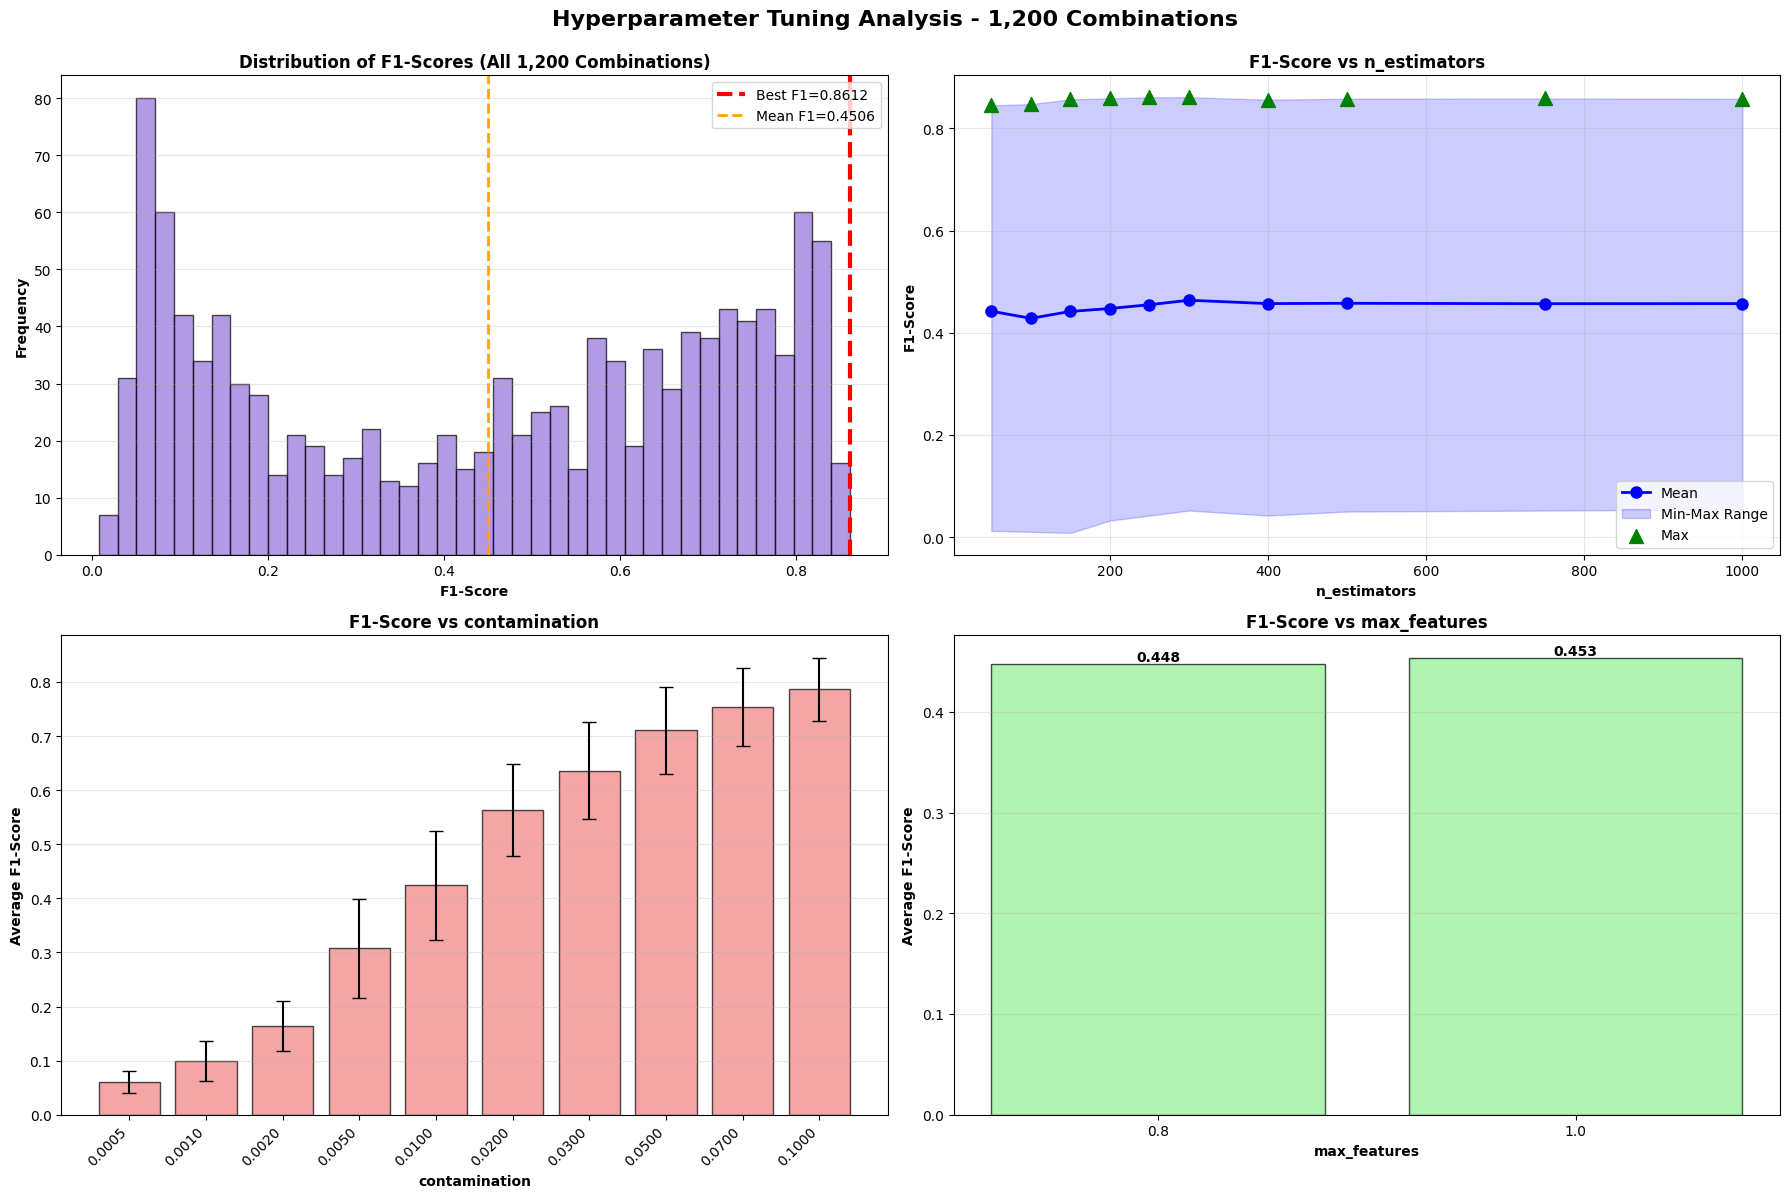

✓ Saved: hyperparameter_tuning_analysis_1200.png

📈 Summary Statistics:
--------------------------------------------------------------------------------
  Mean F1-Score:   0.4506
  Median F1-Score: 0.4906
  Std F1-Score:    0.2741
  Min F1-Score:    0.0082
  Max F1-Score:    0.8612
  Range:           0.8530

✓ Ready for next step: Threshold Optimization


In [11]:
print("\n[STEP 8] Hyperparameter Tuning - Isolation Forest (1,200 Kombinasi)")
print("="*80)

# ========================================
# DEFINISI PARAMETER GRID (1,200 KOMBINASI)
# ========================================
param_grid = {
    'n_estimators': [50, 100, 150, 200, 250, 300, 400, 500, 750, 1000],  # 10 nilai
    'contamination': [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.03, 0.05, 0.07, 0.10],  # 10 nilai
    'max_samples': [64, 128, 256, 384, 512, 768],  # 6 nilai
    'max_features': [0.8, 1.0]  # 2 nilai
}

# Hitung total kombinasi
total_combos = 1
for param_name, param_values in param_grid.items():
    total_combos *= len(param_values)

print("\n📊 Parameter Grid Configuration:")
print("-" * 80)
for param_name, param_values in param_grid.items():
    print(f"  {param_name:20s}: {len(param_values):2d} values")
print(f"\n  TOTAL KOMBINASI: {total_combos} kombinasi")

# ========================================
# SIAPKAN DATA NORMAL UNTUK TRAINING
# ========================================
mask_norm = (y_train == 0)
X_train_norm_scaled = X_train_scaled[mask_norm]
print(f"\n✓ Training data (normal only): {len(X_train_norm_scaled):,} samples")

# ========================================
# GRID SEARCH DENGAN PROGRESS TRACKING
# ========================================
print("\n🔄 Starting Grid Search (1,200 combinations)...")
print("-" * 80)

results = []
best_f1 = -1
best_params = None
best_model = None

start_time = time.time()
combo_num = 0
last_best_update = 0
last_progress_print = 0

# Log file untuk tracking
log_file = OUTPUT_DIR / 'hyperparameter_tuning_progress.log'
with open(log_file, 'w') as f:
    f.write(f"Hyperparameter Tuning Progress Log\n")
    f.write(f"Start time: {datetime.now()}\n")
    f.write(f"Total combinations: {total_combos}\n")
    f.write("="*80 + "\n\n")

print(f"Log file: {log_file}")

# NESTED LOOP - SEKARANG BENAR DENGAN 4 LOOP
for n_est in param_grid['n_estimators']:
    for contam in param_grid['contamination']:
        for max_samp in param_grid['max_samples']:
            for max_feat in param_grid['max_features']: 
                combo_num += 1
                
                current_params = {
                    'n_estimators': n_est,
                    'contamination': contam,
                    'max_samples': max_samp,
                    'max_features': max_feat,  
                    'random_state': RANDOM_STATE,
                    'n_jobs': -1,
                    'verbose': 0
                }
                
                # ========================================
                # PROGRESS INDICATOR (Setiap 25 kombinasi)
                # ========================================
                if combo_num % 25 == 1 or combo_num == total_combos:
                    elapsed = time.time() - start_time
                    rate = combo_num / elapsed if elapsed > 0 else 0
                    remaining = total_combos - combo_num
                    eta = remaining / rate if rate > 0 else 0
                    percent = (combo_num / total_combos) * 100
                    
                    progress_msg = (
                        f"\n[{combo_num:4d}/{total_combos}] "
                        f"Progress: {percent:5.1f}% | "
                        f"Elapsed: {elapsed/60:6.1f}min | "
                        f"ETA: {eta/60:6.1f}min | "
                        f"Rate: {rate:.1f} combo/sec"
                    )
                    print(progress_msg)
                    
                    # Tulis ke log file
                    with open(log_file, 'a') as f:
                        f.write(progress_msg + "\n")
                
                # ========================================
                # DETAIL INFORMASI (Setiap 50 kombinasi)
                # ========================================
                if combo_num % 50 == 0 or combo_num == 1:
                    detail_msg = (
                        f"  Combo #{combo_num}: "
                        f"n_est={n_est:4d} | contam={contam:.4f} | "
                        f"max_samp={max_samp:3d} | max_feat={max_feat:.1f}"
                    )
                    print(detail_msg)
                    with open(log_file, 'a') as f:
                        f.write(detail_msg + "\n")
                
                # ========================================
                # TRAINING & EVALUATION
                # ========================================
                try:
                    # Train model
                    model = IsolationForest(**current_params)
                    model.fit(X_train_norm_scaled)
                    
                    # Predict di VALIDATION
                    y_val_pred = model.predict(X_val_scaled)
                    y_val_pred = np.where(y_val_pred == -1, 1, 0)
                    
                    # Hitung metrik
                    precision = precision_score(y_val, y_val_pred, zero_division=0)
                    recall = recall_score(y_val, y_val_pred, zero_division=0)
                    f1 = f1_score(y_val, y_val_pred, zero_division=0)
                    
                    # Simpan hasil
                    results.append({
                        'combo_number': combo_num,
                        'n_estimators': n_est,
                        'contamination': contam,
                        'max_samples': max_samp,
                        'max_features': max_feat,
                        'precision': precision,
                        'recall': recall,
                        'f1': f1
                    })
                    
                    # Update best
                    if f1 > best_f1:
                        best_f1 = f1
                        best_params = current_params.copy()
                        best_model = model
                        last_best_update = combo_num
                        
                        best_msg = (
                            f"   NEW BEST at combo #{combo_num}! "
                            f"F1={best_f1:.4f} | P={precision:.4f} | R={recall:.4f} | "
                            f"n_est={n_est} | contam={contam} | max_samp={max_samp} | max_feat={max_feat}"
                        )
                        print(best_msg)
                        with open(log_file, 'a') as f:
                            f.write(best_msg + "\n")
                
                except Exception as e:
                    error_msg = f"  ❌ Combo #{combo_num} Error: {str(e)[:60]}"
                    print(error_msg)
                    with open(log_file, 'a') as f:
                        f.write(error_msg + "\n")
                    continue

total_time = time.time() - start_time

# ========================================
# HASIL TUNING
# ========================================
print("\n" + "="*80)
print("✓ HYPERPARAMETER TUNING COMPLETED!")
print("="*80)

summary = f"""
Total waktu: {total_time/60:.1f} menit ({total_time/3600:.2f} jam)
Kombinasi berhasil: {len(results)}/{total_combos}
Last best update at combination: #{last_best_update}
Improvement rate: {(len(results)/total_combos)*100:.1f}% success rate

BEST PARAMETERS (Kombinasi #{last_best_update}):
"""
print(summary)
print("-" * 60)
print(f"  n_estimators:  {best_params['n_estimators']}")
print(f"  contamination: {best_params['contamination']}")
print(f"  max_samples:   {best_params['max_samples']}")
print(f"  max_features:  {best_params['max_features']}")
print(f"  Best F1-Score: {best_f1:.4f}")

# Tulis summary ke log
with open(log_file, 'a') as f:
    f.write("\n" + "="*80 + "\n")
    f.write("FINAL SUMMARY\n")
    f.write("="*80 + "\n")
    f.write(summary)
    f.write(f"  n_estimators:  {best_params['n_estimators']}\n")
    f.write(f"  contamination: {best_params['contamination']}\n")
    f.write(f"  max_samples:   {best_params['max_samples']}\n")
    f.write(f"  max_features:  {best_params['max_features']}\n")
    f.write(f"  Best F1-Score: {best_f1:.4f}\n")
    f.write(f"End time: {datetime.now()}\n")

# Simpan hasil ke CSV
results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
results_df.to_csv(OUTPUT_DIR / 'hyperparameter_tuning_results_1200.csv', index=False)
print(f"\n✓ Saved results: hyperparameter_tuning_results_1200.csv ({len(results_df)} rows)")
print(f"✓ Saved log: {log_file}")

# Print top 10
print(f"\n📊 Top 10 Kombinasi:")
print("-" * 80)
top_10 = results_df.head(10)[['combo_number', 'n_estimators', 'contamination', 'max_samples', 'max_features', 'f1', 'precision', 'recall']]
print(top_10.to_string(index=False))

# Gunakan model terbaik
if_model = best_model

# ========================================
# VISUALISASI HASIL TUNING
# ========================================
print("\n📈 Creating tuning visualization...")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: F1 distribution
ax = axes[0, 0]
ax.hist(results_df['f1'], bins=40, color='mediumpurple', edgecolor='black', alpha=0.7)
ax.axvline(best_f1, color='red', linestyle='--', linewidth=3, label=f'Best F1={best_f1:.4f}')
ax.axvline(results_df['f1'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean F1={results_df["f1"].mean():.4f}')
ax.set_xlabel('F1-Score', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Distribution of F1-Scores (All 1,200 Combinations)', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 2: F1 vs n_estimators
ax = axes[0, 1]
grouped = results_df.groupby('n_estimators')['f1'].agg(['mean', 'max', 'min'])
ax.plot(grouped.index, grouped['mean'], 'o-', color='blue', linewidth=2, markersize=8, label='Mean')
ax.fill_between(grouped.index, grouped['min'], grouped['max'], alpha=0.2, color='blue', label='Min-Max Range')
ax.scatter(grouped.index, grouped['max'], color='green', s=100, marker='^', zorder=5, label='Max')
ax.set_xlabel('n_estimators', fontweight='bold')
ax.set_ylabel('F1-Score', fontweight='bold')
ax.set_title('F1-Score vs n_estimators', fontweight='bold')
ax.grid(alpha=0.3)
ax.legend()

# Plot 3: F1 vs contamination
ax = axes[1, 0]
grouped = results_df.groupby('contamination')['f1'].agg(['mean', 'max', 'std'])
x_pos = range(len(grouped))
ax.bar(x_pos, grouped['mean'], yerr=grouped['std'], capsize=5, 
       color='lightcoral', edgecolor='black', alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'{x:.4f}' for x in grouped.index], rotation=45, ha='right')
ax.set_xlabel('contamination', fontweight='bold')
ax.set_ylabel('Average F1-Score', fontweight='bold')
ax.set_title('F1-Score vs contamination', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Plot 4: F1 vs max_features
ax = axes[1, 1]
grouped = results_df.groupby('max_features')['f1'].agg(['mean', 'max', 'count'])
x_labels = [f'{x:.1f}' for x in grouped.index]
ax.bar(range(len(grouped)), grouped['mean'], color='lightgreen', edgecolor='black', alpha=0.7)
ax.set_xticks(range(len(grouped)))
ax.set_xticklabels(x_labels)
ax.set_xlabel('max_features', fontweight='bold')
ax.set_ylabel('Average F1-Score', fontweight='bold')
ax.set_title('F1-Score vs max_features', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(grouped['mean'].values):
    ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Hyperparameter Tuning Analysis - 1,200 Combinations', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hyperparameter_tuning_analysis_1200.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: hyperparameter_tuning_analysis_1200.png")

# Summary statistics
print(f"\n📈 Summary Statistics:")
print("-" * 80)
print(f"  Mean F1-Score:   {results_df['f1'].mean():.4f}")
print(f"  Median F1-Score: {results_df['f1'].median():.4f}")
print(f"  Std F1-Score:    {results_df['f1'].std():.4f}")
print(f"  Min F1-Score:    {results_df['f1'].min():.4f}")
print(f"  Max F1-Score:    {results_df['f1'].max():.4f}")
print(f"  Range:           {results_df['f1'].max() - results_df['f1'].min():.4f}")

print(f"\n✓ Ready for next step: Threshold Optimization")
print("="*80)

## 9) Threshold Optimization + Model Evaluation

In [ ]:
print("\n[STEP 9] Threshold Optimization + Model Evaluation...")
print("="*80)
print("Model terbaik dari hyperparameter tuning akan digunakan.")
print(f"Best params: n_estimators={best_params['n_estimators']}, "
      f"contamination={best_params['contamination']}, "
      f"max_samples={best_params['max_samples']}")
print("\nSekarang mencari threshold optimal di Validation Set...")
print("-" * 80)

# 1) Ambil SKOR dari model (decision_function: makin besar = makin normal) → balik tanda jadi anomali
y_train_scores = if_model.decision_function(X_train_scaled)
y_val_scores   = if_model.decision_function(X_val_scaled)
y_test_scores  = if_model.decision_function(X_test_scaled)

anom_train = -y_train_scores
anom_val   = -y_val_scores
anom_test  = -y_test_scores

# 2) TENTUKAN THRESHOLD di VALIDATION dengan TARGET PRECISION
import numpy as np
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    precision_recall_curve
)

TARGET_PREC = 0.75   
best_th = None

# 2a) Coba threshold dengan syarat precision >= TARGET_PREC, pilih recall tertinggi
prec, rec, ths = precision_recall_curve(y_val, anom_val)  
idx = np.where(prec[:-1] >= TARGET_PREC)[0]               

if len(idx) > 0:
    best_i = idx[np.argmax(rec[idx])]
    best_th = ths[best_i]
    print(f"[VAL] Precision≥{TARGET_PREC:.2f} → P={prec[best_i]:.3f}, R={rec[best_i]:.3f}, Thr={best_th:.6f}")
else:
    # 2b) Fallback: maksimalkan F2 (lebih menekankan recall)
    beta = 2.0
    f2 = (1+beta**2) * (prec[:-1]*rec[:-1]) / (beta**2*prec[:-1] + rec[:-1] + 1e-12)
    best_i = int(np.argmax(f2))
    best_th = ths[best_i]
    print(f"[VAL] F2 max fallback → P={prec[best_i]:.3f}, R={rec[best_i]:.3f}, Thr={best_th:.6f}")

# 2c) Fallback terakhir (sangat jarang): grid F1 jika best_th masih None
if best_th is None or not np.isfinite(best_th):
    qs = np.linspace(0.50, 0.999, 600)   # grid lebih lebar agar recall bisa naik
    best_f1, best_th_f1 = -1, None
    for q in qs:
        th = np.quantile(anom_val, q)
        y_val_pred_th = (anom_val >= th).astype(int)
        f1 = f1_score(y_val, y_val_pred_th, zero_division=0)
        if f1 > best_f1:
            best_f1, best_th_f1 = f1, th
    best_th = best_th_f1
    print(f"[VAL] F1 grid fallback → Best F1={best_f1:.3f} @ Thr={best_th:.6f}")

# Safety fallback
if best_th is None or not np.isfinite(best_th):
    best_th = np.quantile(anom_val, 0.99)
    print(f"[VAL] Safety fallback → Thr={best_th:.6f}")

# 3) BEKUKAN AMBANG → buat prediksi BINER untuk TRAIN/VAL/TEST
th_final = best_th
y_train_pred = (anom_train >= th_final).astype(int)
y_val_pred   = (anom_val   >= th_final).astype(int)
y_test_pred  = (anom_test  >= th_final).astype(int)
print("✓ Predictions completed with tuned threshold.")

# 4) AUC pakai SKOR KONTINYU (bukan y_pred)
from sklearn.metrics import average_precision_score, roc_auc_score
roc  = roc_auc_score(y_test, anom_test)
pr   = average_precision_score(y_test, anom_test)
print(f"[TEST] ROC-AUC={roc:.3f}  PR-AUC={pr:.3f}")

# 5) Metrik biner
from sklearn.metrics import confusion_matrix, matthews_corrcoef

def calculate_metrics(y_true, y_pred, set_name):
    """Calculate comprehensive metrics"""
    print(f"\n{set_name} Set Metrics:")
    print("-" * 60)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    mcc       = matthews_corrcoef(y_true, y_pred)

    accuracy    = (tp + tn) / (tp + tn + fp + fn) if (tp+tn+fp+fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fpr         = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr         = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    print("Confusion Matrix:")
    print(f"  TN: {tn:,}  |  FP: {fp:,}")
    print(f"  FN: {fn:,}  |  TP: {tp:,}")
    print("\nPerformance Metrics:")
    print(f"  Accuracy:    {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision:   {precision:.4f} ({precision*100:.2f}%)")
    print(f"  Recall:      {recall:.4f} ({recall*100:.2f}%)")
    print(f"  F1-Score:    {f1:.4f}")
    print(f"  MCC:         {mcc:.4f}")
    print(f"  Specificity: {specificity:.4f} ({specificity*100:.2f}%)")
    print(f"  FPR:         {fpr:.4f} ({fpr*100:.2f}%)")
    print(f"  FNR:         {fnr:.4f} ({fnr*100:.2f}%)")

    return {
        'set_name': set_name, 'confusion_matrix': cm,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'accuracy': accuracy, 'precision': precision, 'recall': recall,
        'f1': f1, 'mcc': mcc, 'specificity': specificity, 'fpr': fpr, 'fnr': fnr
    }

train_metrics = calculate_metrics(y_train, y_train_pred, "Training")
val_metrics   = calculate_metrics(y_val,   y_val_pred,   "Validation")
test_metrics  = calculate_metrics(y_test,  y_test_pred,  "Test")

all_metrics = {'train': train_metrics, 'val': val_metrics, 'test': test_metrics}

# --- TAMBAHAN: SIMPAN THRESHOLD KE FILE ---
import json

threshold_data = {
    'optimal_threshold': float(th_final),
    'note': 'Threshold derived from Validation Set (Precision >= 0.70)'
}

# Simpan ke file JSON di folder output
with open(OUTPUT_DIR / 'threshold_config.json', 'w') as f:
    json.dump(threshold_data, f, indent=4)

print(f"✓ Threshold berhasil disimpan ke: {OUTPUT_DIR / 'threshold_config.json'}")



[STEP 9] Threshold Optimization + Model Evaluation...
Model terbaik dari hyperparameter tuning akan digunakan.
Best params: n_estimators=300, contamination=0.1, max_samples=768

Sekarang mencari threshold optimal di Validation Set...
--------------------------------------------------------------------------------
[VAL] Precision≥0.75 → P=0.750, R=0.962, Thr=-0.044929
✓ Predictions completed with tuned threshold.
[TEST] ROC-AUC=0.944  PR-AUC=0.928

Training Set Metrics:
------------------------------------------------------------
Confusion Matrix:
  TN: 4,010  |  FP: 1,450
  FN: 243  |  TP: 4,307

Performance Metrics:
  Accuracy:    0.8309 (83.09%)
  Precision:   0.7481 (74.81%)
  Recall:      0.9466 (94.66%)
  F1-Score:    0.8357
  MCC:         0.6860
  Specificity: 0.7344 (73.44%)
  FPR:         0.2656 (26.56%)
  FNR:         0.0534 (5.34%)

Validation Set Metrics:
------------------------------------------------------------
Confusion Matrix:
  TN: 858  |  FP: 312
  FN: 37  |  TP: 93

## 10) VISUALIZATION & ANALYSIS


[STEP 10] Creating Visualizations...
Menghitung metrik di 200 threshold berbeda untuk plot...
Membuat plot...

✓ Plot disimpan: threshold_tuning_plot_FINAL.png
[STEP 9.5] Selesai.

[10.1] Confusion Matrix Comparison...


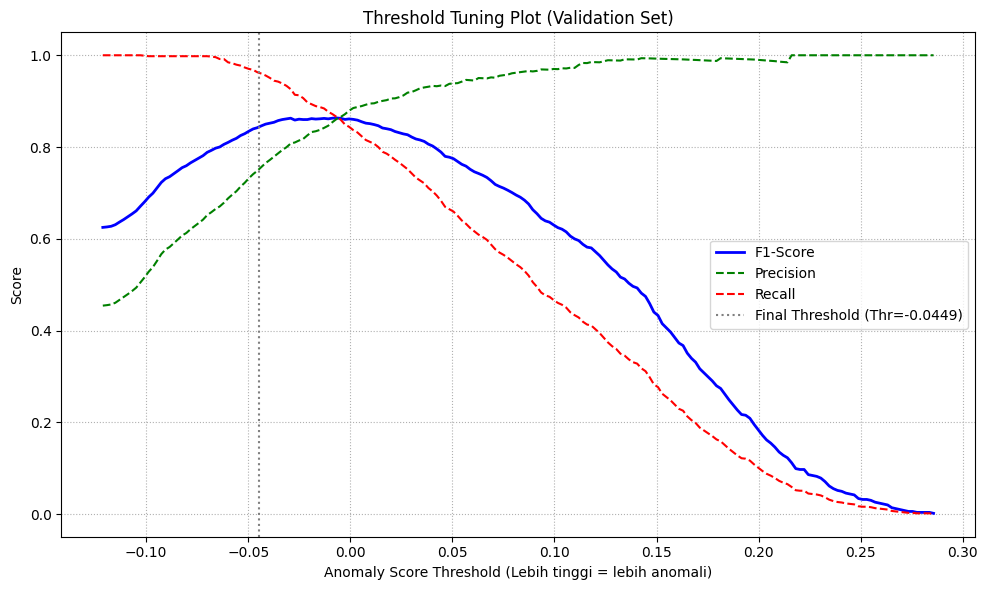

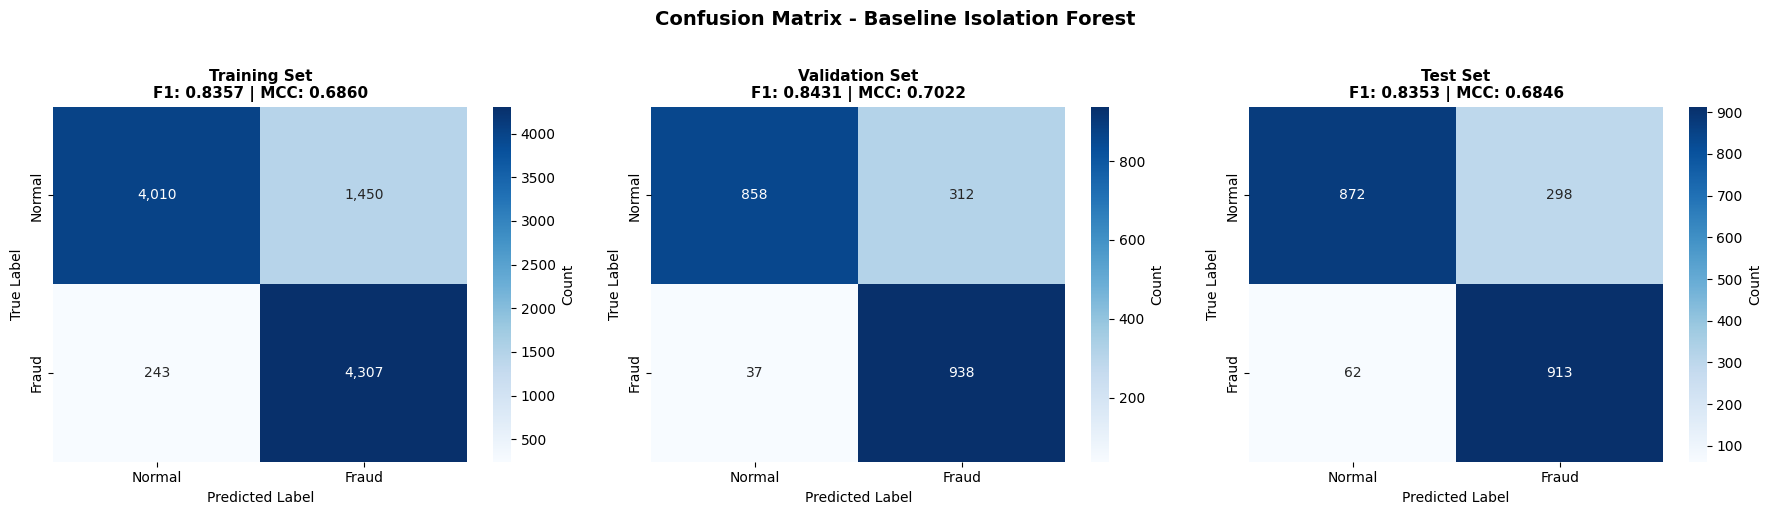

✓ Saved: eval_confusion_matrix.png

[10.2] Metrics Comparison...


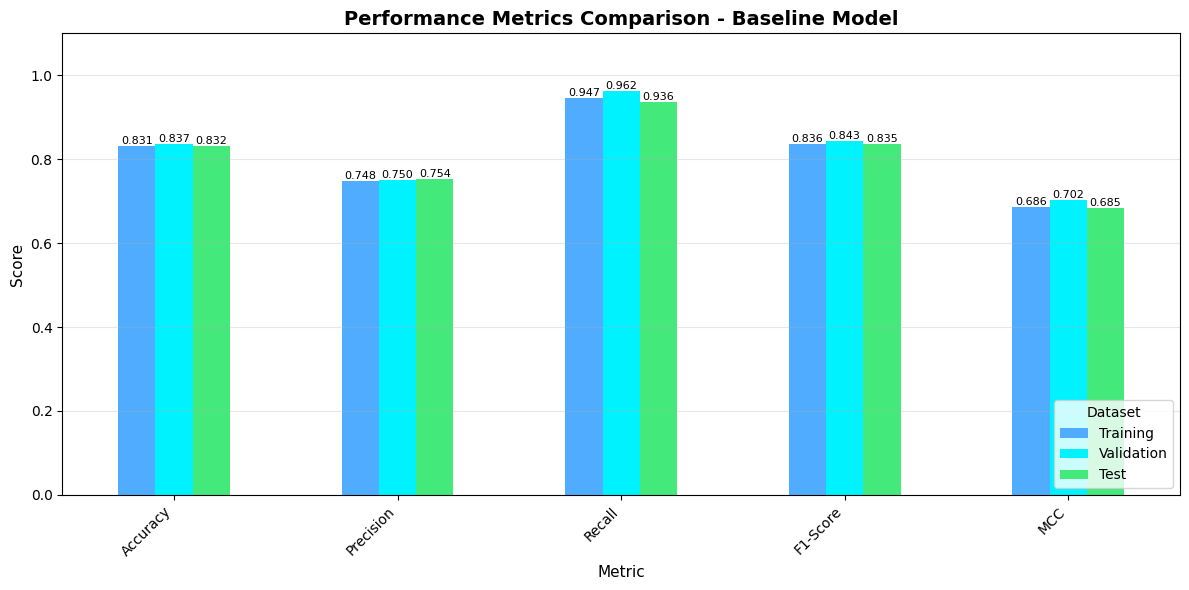

✓ Saved: eval_metrics_comparison.png

[10.3] Anomaly Score Distribution...


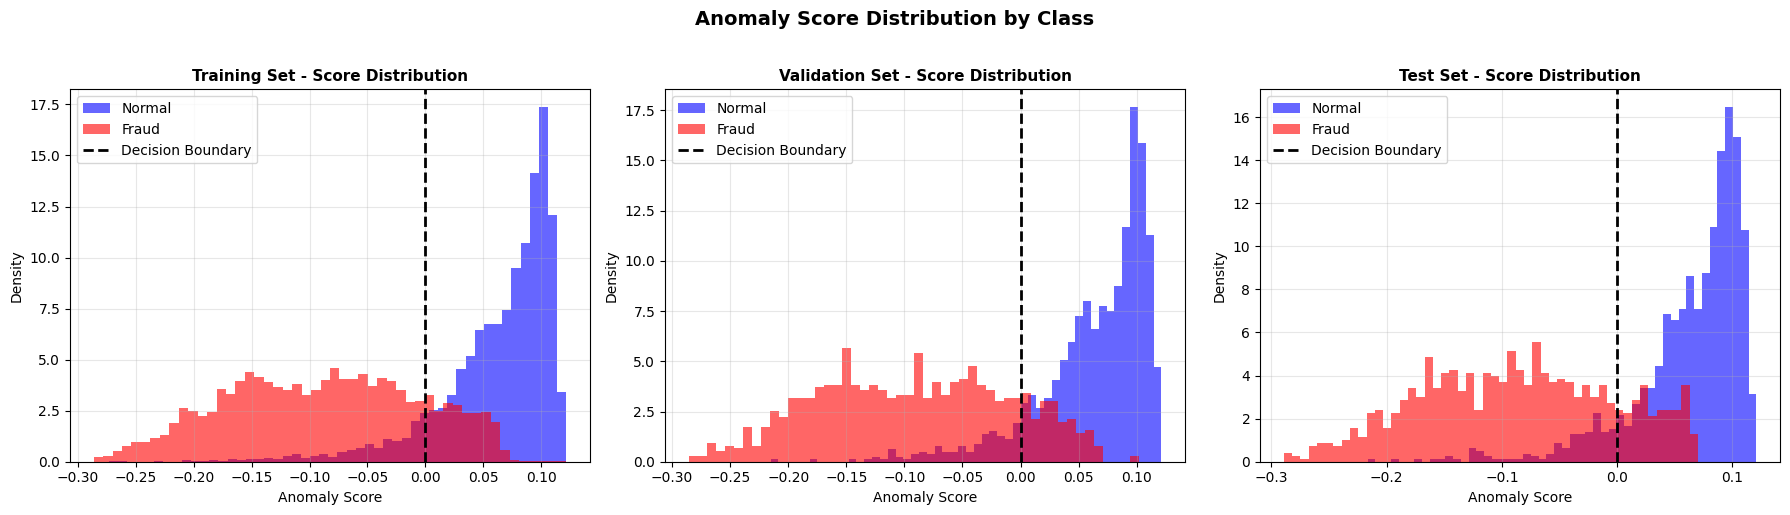

✓ Saved: eval_score_distribution.png

[10.4] Precision-Recall Curve...


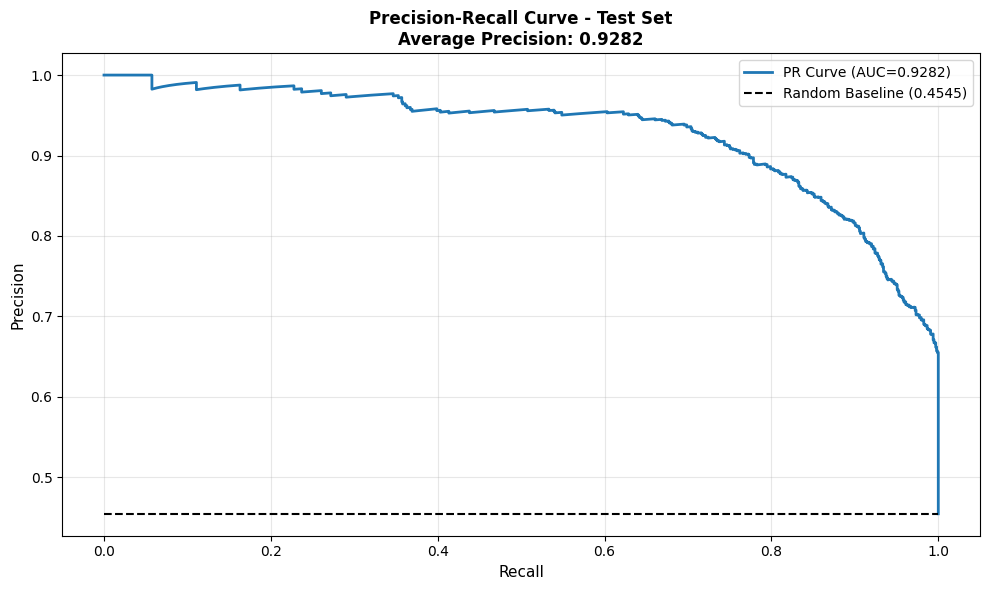

✓ Saved: eval_pr_curve.png

[10.5] ROC Curve...


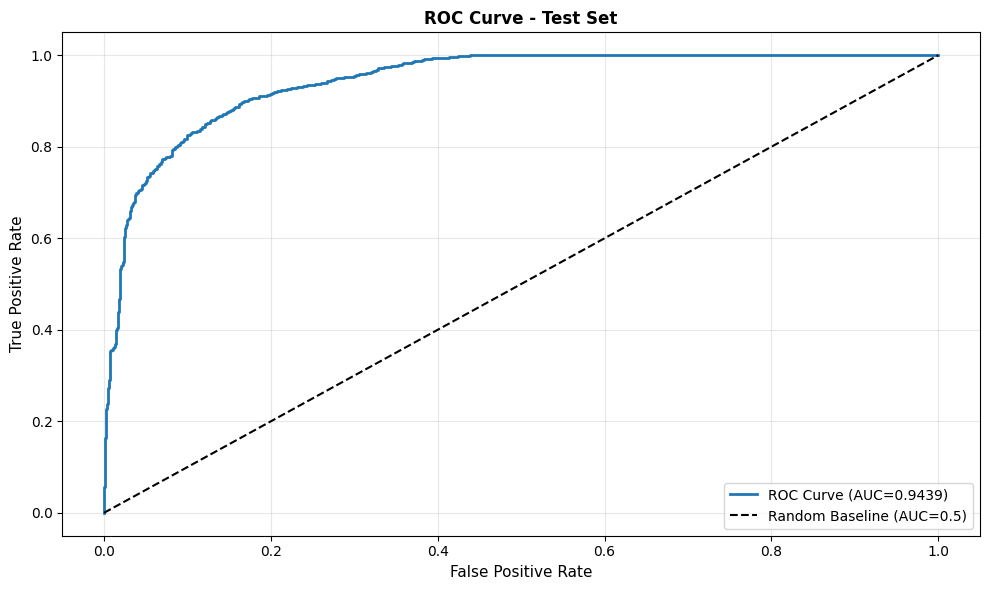

✓ Saved: eval_roc_curve.png


In [ ]:
print("\n[STEP 10] Creating Visualizations...")
print("="*80)

print("Menghitung metrik di 200 threshold berbeda untuk plot...")
thresholds = np.linspace(np.min(anom_val), np.max(anom_val), 200)

results = []
for t in thresholds:
    y_val_pred = (anom_val >= t).astype(int) 
    
    f1 = f1_score(y_val, y_val_pred, zero_division=0)
    p = precision_score(y_val, y_val_pred, zero_division=0)
    r = recall_score(y_val, y_val_pred, zero_division=0)
    
    results.append({'threshold': t, 'f1': f1, 'precision': p, 'recall': r})

# extract data for plot
thresh_vals = [r['threshold'] for r in results]
f1_vals = [r['f1'] for r in results]
p_vals = [r['precision'] for r in results]
r_vals = [r['recall'] for r in results]

# make plot
print("Membuat plot...")
plt.figure(figsize=(10, 6))

plt.plot(thresh_vals, f1_vals, label='F1-Score', color='blue', linewidth=2)
plt.plot(thresh_vals, p_vals, label='Precision', color='green', linestyle='--')
plt.plot(thresh_vals, r_vals, label='Recall', color='red', linestyle='--')

# take final threshold from Step 9
BEST_THRESHOLD = th_final 

# mark best threshold value
plt.axvline(x=BEST_THRESHOLD, color='grey', linestyle=':', 
            label=f'Final Threshold (Thr={BEST_THRESHOLD:.4f})')

plt.title('Threshold Tuning Plot (Validation Set)')
plt.xlabel('Anomaly Score Threshold (Lebih tinggi = lebih anomali)')
plt.ylabel('Score')
plt.legend(loc='best')
plt.grid(True, linestyle=':')
plt.tight_layout()

# save plot
plt.savefig(OUTPUT_DIR / 'threshold_tuning_plot_FINAL.png')

print(f"\n✓ Plot disimpan: threshold_tuning_plot_FINAL.png")
print("[STEP 9.5] Selesai.")

# 10.1) Confusion Matrix Comparison
print("\n[10.1] Confusion Matrix Comparison...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (metrics, ax) in enumerate(zip([train_metrics, val_metrics, test_metrics], axes)):
    cm = metrics['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt=',.0f', cmap='Blues', ax=ax,
                cbar_kws={'label': 'Count'})
    ax.set_title(f"{metrics['set_name']} Set\nF1: {metrics['f1']:.4f} | MCC: {metrics['mcc']:.4f}",
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticklabels(['Normal', 'Fraud'])
    ax.set_yticklabels(['Normal', 'Fraud'])

plt.suptitle('Confusion Matrix - Baseline Isolation Forest', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eval_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: eval_confusion_matrix.png")

# 10.2) Metrics Comparison
print("\n[10.2] Metrics Comparison...")
metrics_df = pd.DataFrame({
    'Training': [train_metrics['accuracy'], train_metrics['precision'], 
                 train_metrics['recall'], train_metrics['f1'], train_metrics['mcc']],
    'Validation': [val_metrics['accuracy'], val_metrics['precision'], 
                   val_metrics['recall'], val_metrics['f1'], val_metrics['mcc']],
    'Test': [test_metrics['accuracy'], test_metrics['precision'], 
             test_metrics['recall'], test_metrics['f1'], test_metrics['mcc']]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'MCC'])

fig, ax = plt.subplots(figsize=(12, 6))
metrics_df.plot(kind='bar', ax=ax, color=['#4facfe', '#00f2fe', '#43e97b'])
ax.set_title('Performance Metrics Comparison - Baseline Model', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Metric', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')
ax.legend(title='Dataset', loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eval_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: eval_metrics_comparison.png")

# 10.3) Anomaly Score Distribution
print("\n[10.3] Anomaly Score Distribution...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (scores, y_true, set_name, ax) in enumerate(zip(
    [y_train_scores, y_val_scores, y_test_scores],
    [y_train, y_val, y_test],
    ['Training', 'Validation', 'Test'],
    axes
)):
    ax.hist(scores[y_true == 0], bins=50, alpha=0.6, label='Normal', color='blue', density=True)
    ax.hist(scores[y_true == 1], bins=50, alpha=0.6, label='Fraud', color='red', density=True)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Decision Boundary')
    ax.set_xlabel('Anomaly Score', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'{set_name} Set - Score Distribution', fontweight='bold', fontsize=11)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Anomaly Score Distribution by Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eval_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: eval_score_distribution.png")

# 10.4) Precision-Recall Curve
print("\n[10.4] Precision-Recall Curve...")
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, -y_test_scores)
pr_auc = auc(recall_vals, precision_vals)
avg_precision = average_precision_score(y_test, -y_test_scores)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(recall_vals, precision_vals, linewidth=2, label=f'PR Curve (AUC={pr_auc:.4f})')
ax.plot([0, 1], [y_test.mean(), y_test.mean()], 'k--', 
        label=f'Random Baseline ({y_test.mean():.4f})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title(f'Precision-Recall Curve - Test Set\nAverage Precision: {avg_precision:.4f}',
             fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eval_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: eval_pr_curve.png")

# 10.5) ROC Curve
print("\n[10.5] ROC Curve...")
fpr, tpr, roc_thresholds = roc_curve(y_test, -y_test_scores)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC={roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', label='Random Baseline (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve - Test Set', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eval_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: eval_roc_curve.png")

In [14]:
print("Membuat file demo 'HANYA NORMAL'...")

# 1. Muat DATA_PATH asli (yang ada di Step 1)
try:
    df_full_original = pd.read_csv(DATA_PATH)
    print(f"Berhasil memuat dataset asli: {DATA_PATH}")
except NameError:
    print("ERROR: Variabel DATA_PATH tidak ditemukan.")
    print("Harap jalankan ulang sel Step 1, lalu jalankan sel ini lagi.")
    
# 2. Ambil HANYA data normal
df_normal_all = df_full_original[df_full_original['isFraud'] == 0]
print(f"Total data normal yang tersedia: {len(df_normal_all):,}")

# 3. Ambil sampel (misal: 5.000 baris) untuk pengujian
N_SAMPEL = 5000
df_normal_test = df_normal_all.sample(n=N_SAMPEL, random_state=RANDOM_STATE)

# 4. Hapus kolom label (karena ini file 'input')
df_normal_test_no_label = df_normal_test.drop(columns=['isFraud'])

# 5. Simpan ke folder output Anda
# Pastikan OUTPUT_DIR sudah terdefinisi dari sel Step 1
try:
    output_path = OUTPUT_DIR / 'demo_HANYA_NORMAL.csv'
    df_normal_test_no_label.to_csv(output_path, index=False)
    
    print("\n--- SELESAI! ---")
    print(f"File demo baru Anda telah disimpan di:")
    print(output_path)
    
except NameError:
    print("ERROR: Variabel OUTPUT_DIR tidak ditemukan.")
    print("Harap jalankan ulang sel Step 1, lalu jalankan sel ini lagi.")
    
# --- Akhir Kode ---

Membuat file demo 'HANYA NORMAL'...
Berhasil memuat dataset asli: D:\Alvin\UBM\Skripsi\coding\PS_20174392719_1491204439457_log.csv
Total data normal yang tersedia: 6,354,407

--- SELESAI! ---
File demo baru Anda telah disimpan di:
baseline_results\demo_HANYA_NORMAL.csv


In [18]:
model_path = OUTPUT_DIR / 'isolation_forest_baseline.pkl'
joblib.dump(if_model, model_path)
print(f"✓ Model saved to: {model_path}")

✓ Model saved to: baseline_results\isolation_forest_baseline.pkl
